# 🧬 Mitotic Figure Classification using Hybrid SE + CCA Attention

## 🎯 Project Overview: 
**Advanced deep learning approach for mitotic figure classification using DenseNet-121 backbone enhanced with hybrid attention mechanisms:**

- **SE (Squeeze-and-Excitation)**: Channel-wise attention for feature recalibration
- **CCA (Coordinate Channel Attention)**: Spatial-coordinate aware attention mechanism  
- **DenseNet-121**: Dense feature connections for robust representation learning
- **Full model training**: End-to-end training (entire DenseNet-121 + SE + CCA + custom head trainable)

## 🌟 Key Features:
- Hybrid SE + CCA attention for enhanced feature learning
- Advanced class balancing with Focal Loss + WeightedRandomSampler
- Comprehensive data augmentation and preprocessing
- Full model training for optimal performance

In [2]:
# # Install PyTorch and required packages
# import sys
# print(f"Python version: {sys.version}")

# # Update pip first
# ! python -m pip install --upgrade pip

# # Install PyTorch (CPU version for compatibility, change to CUDA if needed)
# ! pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu

# # Install other required packages
# ! pip install opencv-python pillow scikit-learn seaborn matplotlib pandas numpy albumentations timm tqdm

# # Verify installation
# try:
#     import torch
#     print(f"PyTorch successfully installed: {torch.__version__}")
#     print(f"CUDA Available: {torch.cuda.is_available()}")
#     if torch.cuda.is_available():
#         print(f"CUDA Device: {torch.cuda.get_device_name(0)}")
# except ImportError as e:
#     print(f"PyTorch installation failed: {e}")

In [3]:
# Core libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Image processing
import cv2
from PIL import Image
import albumentations as A
from albumentations.pytorch import ToTensorV2

# Deep learning
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.optim.lr_scheduler import ReduceLROnPlateau
import torchvision.transforms as transforms
import torchvision.models as models

# Machine learning utilities
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Plotting style
plt.style.use('default')
sns.set_palette("husl")

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

print("All libraries imported successfully!")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")

All libraries imported successfully!
PyTorch version: 2.6.0+cu124
CUDA available: True
CUDA device: Tesla P100-PCIE-16GB


In [4]:
# Set random seeds for reproducibility
import random

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# Define paths for your Kaggle dataset structure
BASE_DIR = Path('/kaggle/input/mitoticfigure-spiltandaugmenteddataset/MitoticFigure_AugmentedDataset')
TRAINING_DIR = BASE_DIR / 'training'
VALIDATION_DIR = BASE_DIR / 'validation'
TESTING_DIR = BASE_DIR / 'testing'
DATASET_CSV = BASE_DIR / 'mitotic_figures_dataset.csv'

print(f"📁 Dataset paths for your pre-split Kaggle dataset:")
print(f"Base directory: {BASE_DIR}")
print(f"Training images: {TRAINING_DIR}")
print(f"Validation images: {VALIDATION_DIR}")
print(f"Testing images: {TESTING_DIR}")
print(f"Dataset CSV: {DATASET_CSV}")

# Check if directories exist
for dir_path, name in [(TRAINING_DIR, 'Training'), (VALIDATION_DIR, 'Validation'), (TESTING_DIR, 'Testing')]:
    if dir_path.exists():
        print(f"✅ {name} directory found")
    else:
        print(f"❌ {name} directory not found: {dir_path}")

# Training parameters (Optimized for DenseNet-121 with GAP)
IMG_SIZE = 224           # Standard input size for DenseNet-121
BATCH_SIZE = 32          # Good batch size for DenseNet-121
EPOCHS = 50              # Assignment requirement: minimum 50 epochs
LEARNING_RATE = 1e-3     # Learning rate for custom layers only
NUM_CLASSES = 2
PATIENCE = 10            # Assignment requirement: patience = 10 for early stopping

print(f"🎯 DENSENET-121 GAP PARAMETERS:")
print(f"Model: DenseNet-121 + Global Average Pooling")
print(f"Dataset directory: {BASE_DIR}")
print(f"Dataset CSV: {DATASET_CSV}")
print(f"Image size: {IMG_SIZE}x{IMG_SIZE} (standard for DenseNet)")
print(f"Batch size: {BATCH_SIZE}")
print(f"Epochs: {EPOCHS} (minimum as per assignment)")
print(f"Learning rate: {LEARNING_RATE} (custom layers only)")
print(f"Training approach: GAP + FULL MODEL training (entire network)")
print(f"Early stopping patience: {PATIENCE}")
print(f"Using GPU: {torch.cuda.is_available()}")
print(f"Automatic pretrained weights: ✅ (ImageNet DenseNet-121)")

📁 Dataset paths for your pre-split Kaggle dataset:
Base directory: /kaggle/input/mitoticfigure-spiltandaugmenteddataset/MitoticFigure_AugmentedDataset
Training images: /kaggle/input/mitoticfigure-spiltandaugmenteddataset/MitoticFigure_AugmentedDataset/training
Validation images: /kaggle/input/mitoticfigure-spiltandaugmenteddataset/MitoticFigure_AugmentedDataset/validation
Testing images: /kaggle/input/mitoticfigure-spiltandaugmenteddataset/MitoticFigure_AugmentedDataset/testing
Dataset CSV: /kaggle/input/mitoticfigure-spiltandaugmenteddataset/MitoticFigure_AugmentedDataset/mitotic_figures_dataset.csv
✅ Training directory found
✅ Validation directory found
✅ Testing directory found
🎯 DENSENET-121 GAP PARAMETERS:
Model: DenseNet-121 + Global Average Pooling
Dataset directory: /kaggle/input/mitoticfigure-spiltandaugmenteddataset/MitoticFigure_AugmentedDataset
Dataset CSV: /kaggle/input/mitoticfigure-spiltandaugmenteddataset/MitoticFigure_AugmentedDataset/mitotic_figures_dataset.csv
Image 

## Loading Pre-Augmented Dataset

In [5]:
# Load the organized dataset from your Kaggle upload
print("Loading pre-split dataset from Kaggle...")

# Load the CSV with all metadata
df = pd.read_csv(DATASET_CSV)
print(f"Dataset loaded: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

# Display dataset information
print(f"\nDataset Statistics:")
print(f"Total samples: {len(df)}")

# Check split distribution
if 'split' in df.columns:
    split_counts = df['split'].value_counts()
    print(f"\nSplit distribution:")
    for split in ['training', 'validation', 'testing']:
        count = split_counts.get(split, 0)
        percentage = (count / len(df)) * 100 if len(df) > 0 else 0
        print(f"  {split.capitalize()}: {count} samples ({percentage:.1f}%)")
else:
    print("⚠️ No split column found - dataset might not be properly split")

# Check class distribution
class_counts = df['is_atypical'].value_counts()
print(f"\nClass distribution:")
print(f"Normal (False): {class_counts.get(False, 0)}")
print(f"Atypical (True): {class_counts.get(True, 0)}")

# Check augmentation status
if 'is_augmented' in df.columns:
    aug_counts = df['is_augmented'].value_counts()
    print(f"\nAugmentation breakdown:")
    print(f"Original: {aug_counts.get(False, 0)}")
    print(f"Augmented: {aug_counts.get(True, 0)}")

# Check augmentation types
if 'augmentation_type' in df.columns:
    aug_types = df['augmentation_type'].value_counts()
    print(f"\nAugmentation types:")
    for aug_type, count in aug_types.items():
        print(f"  {aug_type}: {count}")

# Check dataset sources
if 'dataset' in df.columns:
    dataset_counts = df['dataset'].value_counts()
    print(f"\nDataset sources:")
    for dataset, count in dataset_counts.items():
        print(f"  {dataset}: {count}")

# Show first few rows
print(f"\nFirst 5 rows:")
print(df[['filename', 'is_atypical', 'split', 'is_augmented']].head())

print(f"\n✅ Dataset loaded successfully!")

Loading pre-split dataset from Kaggle...
Dataset loaded: (19162, 6)
Columns: ['filename', 'is_atypical', 'dataset', 'split', 'is_augmented', 'augmentation_type']

Dataset Statistics:
Total samples: 19162

Split distribution:
  Training: 13586 samples (70.9%)
  Validation: 2788 samples (14.5%)
  Testing: 2788 samples (14.5%)

Class distribution:
Normal (False): 11762
Atypical (True): 7400

Augmentation breakdown:
Original: 13938
Augmented: 5224

Augmentation types:
  1.0: 1306
  2.0: 1306
  3.0: 1306
  4.0: 1306

Dataset sources:
  MIDOG25: 16151
  AMI-BR: 3011

First 5 rows:
           filename  is_atypical     split  is_augmented
0          1371.png        False  training         False
1  TUPAC16_2232.png        False  training         False
2          3733.png         True  training         False
3          9796.png        False  training         False
4          5477.png        False  training         False

✅ Dataset loaded successfully!


In [6]:
# Prepare the dataset for training using pre-split structure
print("Preparing pre-split dataset for training...")

# Create image paths based on the split information
def get_image_path(row):
    """Get the full image path based on split folder"""
    split_folder = row['split']
    filename = row['filename']
    
    if split_folder == 'training':
        return str(TRAINING_DIR / filename)
    elif split_folder == 'validation':
        return str(VALIDATION_DIR / filename)
    elif split_folder == 'testing':
        return str(TESTING_DIR / filename)
    else:
        # Fallback - try to find the file in any folder
        for folder in [TRAINING_DIR, VALIDATION_DIR, TESTING_DIR]:
            path = folder / filename
            if path.exists():
                return str(path)
        return str(TRAINING_DIR / filename)  # Default fallback

# Add image paths
df['image_path'] = df.apply(get_image_path, axis=1)

# Convert boolean to integer labels (0=Normal, 1=Atypical)
df['label'] = df['is_atypical'].astype(int)

# Verify file existence and filter out missing files
print("Verifying all image files exist...")
existing_files = []
missing_files = []

for idx, row in df.iterrows():
    if Path(row['image_path']).exists():
        existing_files.append(idx)
    else:
        missing_files.append(row['filename'])

if missing_files:
    print(f"⚠️ Warning: {len(missing_files)} files not found")
    if len(missing_files) <= 10:
        print(f"Missing files: {missing_files}")
    else:
        print(f"First 10 missing files: {missing_files[:10]}")

# Keep only existing files
df = df.loc[existing_files].reset_index(drop=True)

print(f"\nFinal dataset info:")
print(f"Total samples: {len(df)}")
print(f"Samples with existing files: {len(existing_files)}")
print(f"Missing files: {len(missing_files)}")

# Display augmentation breakdown if available
if 'is_augmented' in df.columns:
    aug_breakdown = df['is_augmented'].value_counts()
    print(f"\nAugmentation breakdown:")
    print(f"  Original images: {aug_breakdown.get(False, 0)}")
    print(f"  Augmented images: {aug_breakdown.get(True, 0)}")

# Display final class distribution
print(f"\nFinal class distribution:")
class_dist = df['label'].value_counts()
print(f"  Normal (0): {class_dist.get(0, 0)}")
print(f"  Atypical (1): {class_dist.get(1, 0)}")

# Display split distribution
print(f"\nSplit distribution:")
split_dist = df['split'].value_counts()
for split_name, count in split_dist.items():
    percentage = (count / len(df)) * 100
    print(f"  {split_name}: {count} samples ({percentage:.1f}%)")

print(f"\nSample data:")
print(df[['filename', 'label', 'is_atypical', 'split', 'is_augmented']].head())

Preparing pre-split dataset for training...
Verifying all image files exist...

Final dataset info:
Total samples: 19162
Samples with existing files: 19162
Missing files: 0

Augmentation breakdown:
  Original images: 13938
  Augmented images: 5224

Final class distribution:
  Normal (0): 11762
  Atypical (1): 7400

Split distribution:
  training: 13586 samples (70.9%)
  validation: 2788 samples (14.5%)
  testing: 2788 samples (14.5%)

Sample data:
           filename  label  is_atypical     split  is_augmented
0          1371.png      0        False  training         False
1  TUPAC16_2232.png      0        False  training         False
2          3733.png      1         True  training         False
3          9796.png      0        False  training         False
4          5477.png      0        False  training         False


## Data Visualization and Analysis

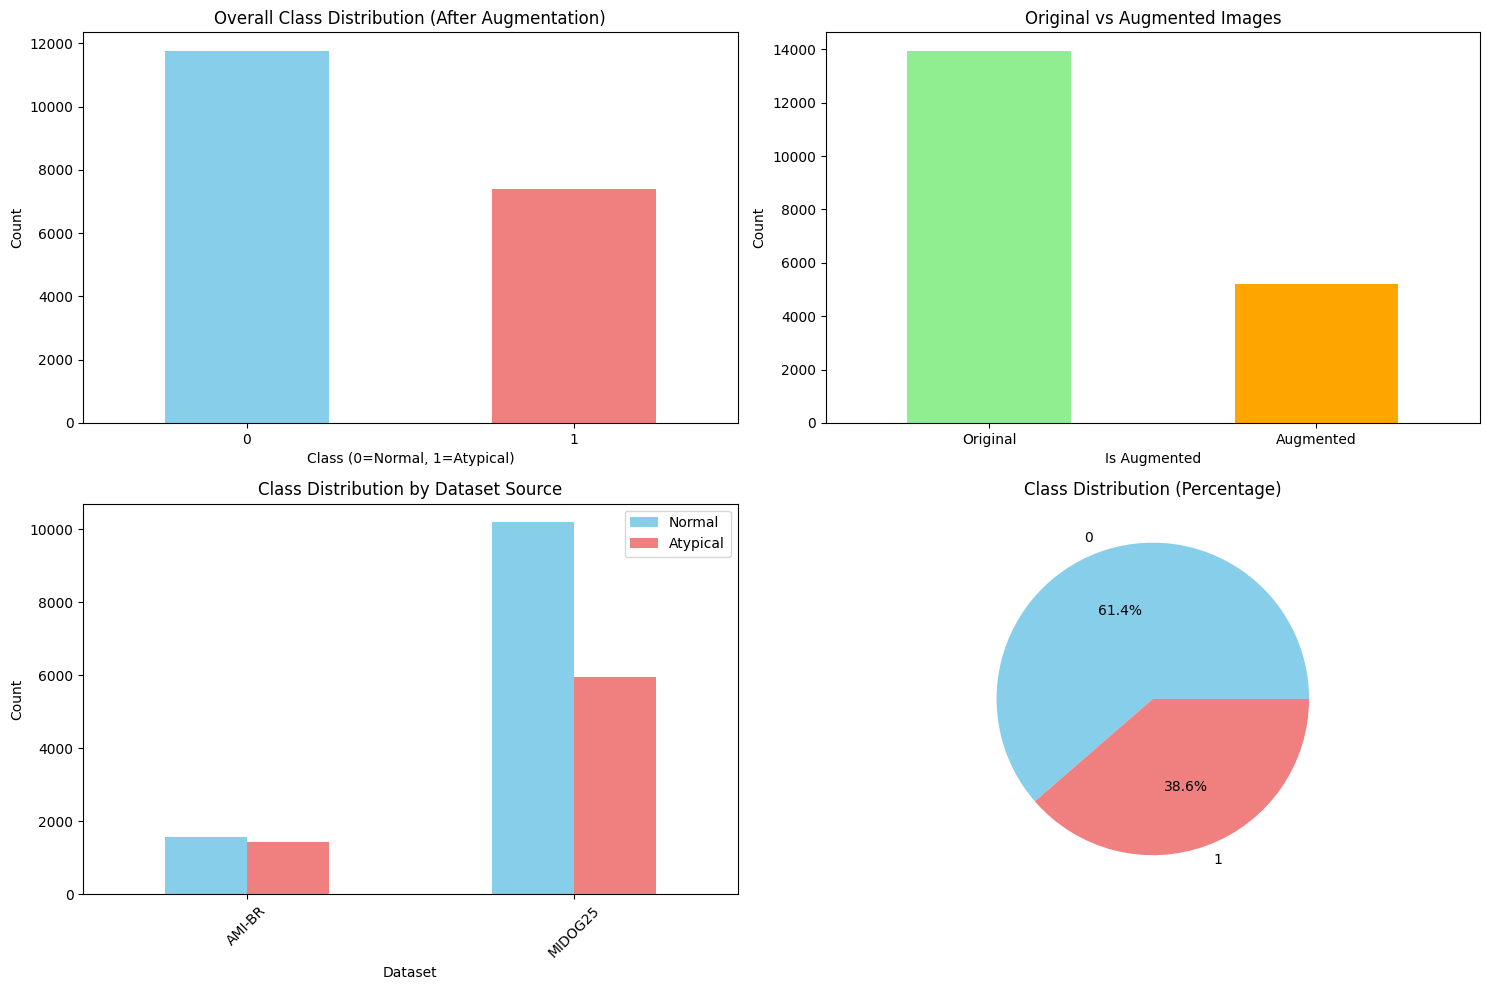

Detailed Statistics:
Total samples: 19162
Normal samples: 11762 (61.4%)
Atypical samples: 7400 (38.6%)

Augmentation breakdown:
Original images: 13938
Augmented images: 5224

By dataset source:
label        0     1    All
dataset                    
AMI-BR    1571  1440   3011
MIDOG25  10191  5960  16151
All      11762  7400  19162

Sample filenames:
['1371.png', 'TUPAC16_2232.png', '3733.png', '9796.png', '5477.png', '11425.png', '1203.png', '7546.png', 'TUPAC16_2410.png', '7783.png']


In [7]:
# Visualize class distribution of pre-augmented dataset
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Overall class distribution
df['label'].value_counts().plot(kind='bar', ax=axes[0,0], color=['skyblue', 'lightcoral'])
axes[0,0].set_title('Overall Class Distribution (After Augmentation)')
axes[0,0].set_xlabel('Class (0=Normal, 1=Atypical)')
axes[0,0].set_ylabel('Count')
axes[0,0].tick_params(axis='x', rotation=0)

# Original vs Augmented distribution (if available)
if 'is_augmented' in df.columns:
    df['is_augmented'].value_counts().plot(kind='bar', ax=axes[0,1], color=['lightgreen', 'orange'])
    axes[0,1].set_title('Original vs Augmented Images')
    axes[0,1].set_xlabel('Is Augmented')
    axes[0,1].set_ylabel('Count')
    axes[0,1].set_xticklabels(['Original', 'Augmented'], rotation=0)
else:
    axes[0,1].text(0.5, 0.5, 'Augmentation info\nnot available', ha='center', va='center', transform=axes[0,1].transAxes)
    axes[0,1].set_title('Original vs Augmented Images')

# Dataset source distribution (if available)
if 'dataset' in df.columns and len(df['dataset'].unique()) > 1:
    pd.crosstab(df['dataset'], df['label']).plot(kind='bar', ax=axes[1,0], 
                                                              color=['skyblue', 'lightcoral'])
    axes[1,0].set_title('Class Distribution by Dataset Source')
    axes[1,0].set_xlabel('Dataset')
    axes[1,0].set_ylabel('Count')
    axes[1,0].legend(['Normal', 'Atypical'])
    axes[1,0].tick_params(axis='x', rotation=45)
else:
    axes[1,0].text(0.5, 0.5, 'Dataset source info\nnot available', ha='center', va='center', transform=axes[1,0].transAxes)
    axes[1,0].set_title('Class Distribution by Dataset Source')

# Percentage distribution
class_pct = df['label'].value_counts(normalize=True) * 100
class_pct.plot(kind='pie', ax=axes[1,1], autopct='%1.1f%%', colors=['skyblue', 'lightcoral'])
axes[1,1].set_title('Class Distribution (Percentage)')
axes[1,1].set_ylabel('')

plt.tight_layout()
plt.show()

# Print detailed statistics
print("Detailed Statistics:")
print(f"Total samples: {len(df)}")
print(f"Normal samples: {len(df[df['label'] == 0])} ({len(df[df['label'] == 0])/len(df)*100:.1f}%)")
print(f"Atypical samples: {len(df[df['label'] == 1])} ({len(df[df['label'] == 1])/len(df)*100:.1f}%)")

if 'is_augmented' in df.columns:
    print(f"\nAugmentation breakdown:")
    print(f"Original images: {len(df[df['is_augmented'] == False])}")
    print(f"Augmented images: {len(df[df['is_augmented'] == True])}")

if 'dataset' in df.columns:
    print(f"\nBy dataset source:")
    if len(df['dataset'].unique()) > 1:
        print(pd.crosstab(df['dataset'], df['label'], margins=True))
    else:
        print(f"Single dataset source: {df['dataset'].iloc[0]}")

# Show file naming patterns
print(f"\nSample filenames:")
print(df['filename'].head(10).tolist())

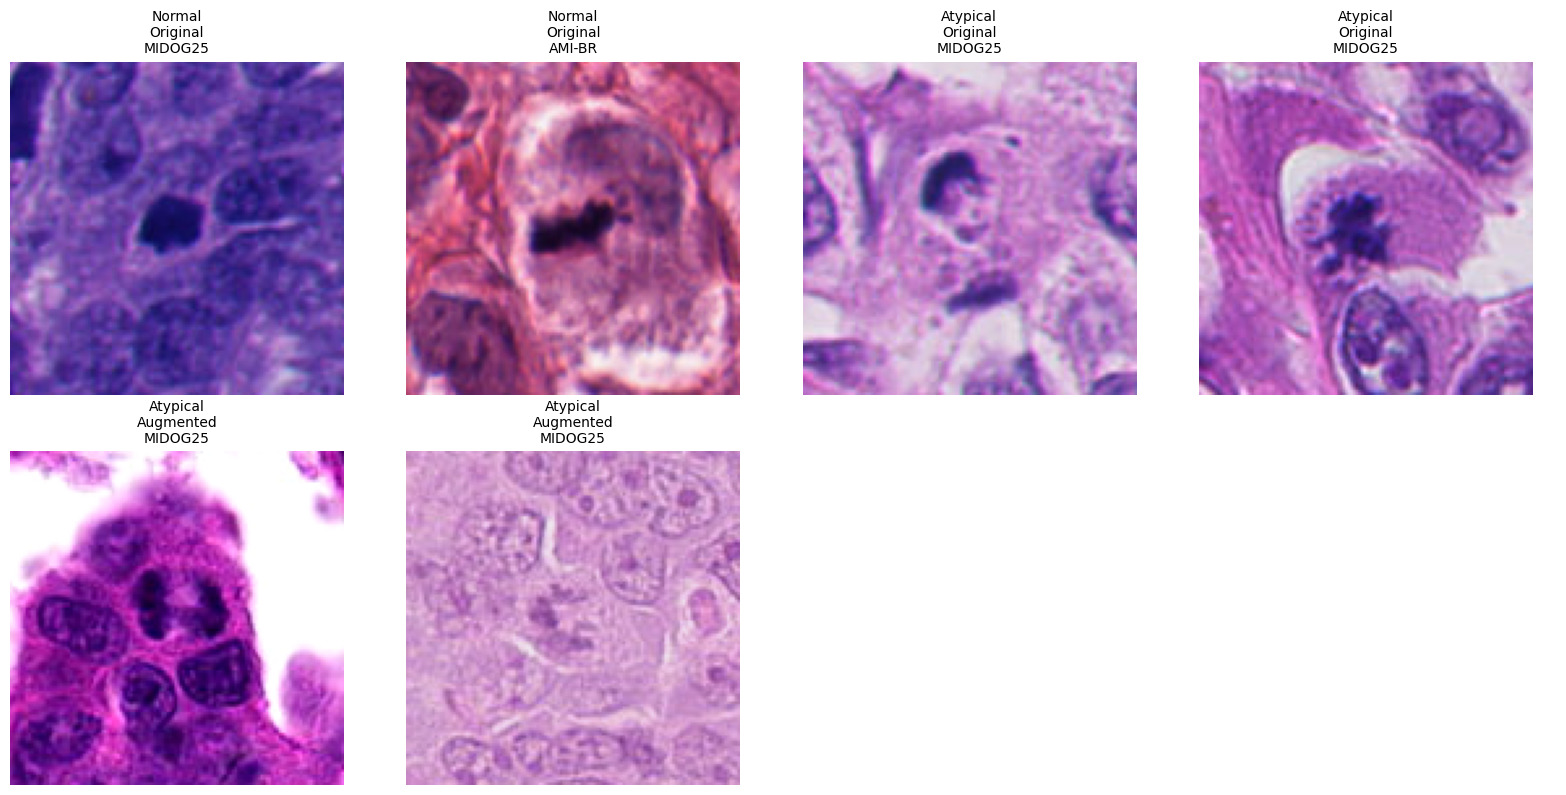

In [8]:
# Sample image visualization
def visualize_samples(df, n_samples=8):
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.ravel()
    
    # Get samples from each class
    samples = []
    
    # Get normal and atypical samples
    for label in [0, 1]:
        subset = df[df['label'] == label]
        if len(subset) > 0:
            # Try to get mix of original and augmented if available
            if 'is_augmented' in df.columns:
                original_subset = subset[subset['is_augmented'] == False]
                augmented_subset = subset[subset['is_augmented'] == True]
                
                # Get 2 original and 2 augmented if possible
                if len(original_subset) > 0:
                    samples.extend(original_subset.sample(min(2, len(original_subset))).to_dict('records'))
                if len(augmented_subset) > 0:
                    samples.extend(augmented_subset.sample(min(2, len(augmented_subset))).to_dict('records'))
            else:
                # Just get 4 samples of this class
                samples.extend(subset.sample(min(4, len(subset))).to_dict('records'))
    
    for i, sample in enumerate(samples[:8]):
        try:
            img = Image.open(sample['image_path'])
            axes[i].imshow(img)
            
            # Create title with available information
            label_text = 'Atypical' if sample['label'] == 1 else 'Normal'
            title_parts = [label_text]
            
            if 'is_augmented' in sample:
                aug_text = 'Augmented' if sample['is_augmented'] else 'Original'
                title_parts.append(aug_text)
            
            if 'dataset' in sample and sample['dataset'] != 'mixed':
                title_parts.append(sample['dataset'])
            
            title = '\n'.join(title_parts)
            axes[i].set_title(title, fontsize=10)
            axes[i].axis('off')
            
        except Exception as e:
            axes[i].text(0.5, 0.5, f"Error loading\n{sample['filename']}", 
                        ha='center', va='center', transform=axes[i].transAxes)
            axes[i].set_title(f"Error: {sample['filename'][:20]}...")
            axes[i].axis('off')
    
    # Hide unused subplots
    for i in range(len(samples), 8):
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()

visualize_samples(df)

## Data Preparation for Training

In [9]:
# Use the pre-split data from your dataset
print("📊 Using pre-split dataset structure...")

# Extract splits based on the 'split' column
train_df = df[df['split'] == 'training'].reset_index(drop=True)
val_df = df[df['split'] == 'validation'].reset_index(drop=True)
test_df = df[df['split'] == 'testing'].reset_index(drop=True)

print(f"📈 Pre-split dataset distribution:")
print(f"Training set: {len(train_df)} samples")
print(f"Validation set: {len(val_df)} samples")
print(f"Test set: {len(test_df)} samples")
print(f"Total: {len(train_df) + len(val_df) + len(test_df)} samples")

# Calculate percentages
total_samples = len(df)
train_pct = len(train_df) / total_samples * 100
val_pct = len(val_df) / total_samples * 100
test_pct = len(test_df) / total_samples * 100

print(f"\n📊 Split percentages:")
print(f"Training: {train_pct:.1f}%")
print(f"Validation: {val_pct:.1f}%")
print(f"Test: {test_pct:.1f}%")

# Check detailed class distribution in each set
print("\n🎯 Class distribution verification:")
for split_name, split_df in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    if len(split_df) > 0:
        class_dist = split_df['label'].value_counts()
        class_pct = split_df['label'].value_counts(normalize=True) * 100
        normal_count = class_dist.get(0, 0)
        atypical_count = class_dist.get(1, 0)
        normal_pct = class_pct.get(0, 0)
        atypical_pct = class_pct.get(1, 0)
        print(f"{split_name}: Normal={normal_count} ({normal_pct:.1f}%), "
              f"Atypical={atypical_count} ({atypical_pct:.1f}%)")

# Check augmentation distribution in each split
if 'is_augmented' in df.columns:
    print("\n🔄 Augmentation distribution by split:")
    for split_name, split_df in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
        if len(split_df) > 0:
            aug_dist = split_df['is_augmented'].value_counts()
            original = aug_dist.get(False, 0)
            augmented = aug_dist.get(True, 0)
            print(f"{split_name}: Original={original}, Augmented={augmented}")

# Verify that we have samples in all splits
if len(train_df) == 0:
    raise ValueError("❌ No training samples found! Check your dataset split column values.")
if len(val_df) == 0:
    raise ValueError("❌ No validation samples found! Check your dataset split column values.")
if len(test_df) == 0:
    raise ValueError("❌ No test samples found! Check your dataset split column values.")

print(f"\n✅ Successfully loaded pre-split dataset!")
print(f"Ready for training with {len(train_df)} training samples")

📊 Using pre-split dataset structure...
📈 Pre-split dataset distribution:
Training set: 13586 samples
Validation set: 2788 samples
Test set: 2788 samples
Total: 19162 samples

📊 Split percentages:
Training: 70.9%
Validation: 14.5%
Test: 14.5%

🎯 Class distribution verification:
Train: Normal=7056 (51.9%), Atypical=6530 (48.1%)
Val: Normal=2353 (84.4%), Atypical=435 (15.6%)
Test: Normal=2353 (84.4%), Atypical=435 (15.6%)

🔄 Augmentation distribution by split:
Train: Original=8362, Augmented=5224
Val: Original=2788, Augmented=0
Test: Original=2788, Augmented=0

✅ Successfully loaded pre-split dataset!
Ready for training with 13586 training samples


In [10]:
# Define PyTorch Dataset class
class MitosisDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform
    
    def __len__(self):
        return len(self.dataframe)
    
    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        
        # Load image
        try:
            image = cv2.imread(row['image_path'])
            if image is None:
                raise ValueError(f"Could not load image: {row['image_path']}")
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        except Exception as e:
            print(f"Error loading {row['image_path']}: {e}")
            # Return a black image as fallback
            image = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
        
        # Apply transforms
        if self.transform:
            transformed = self.transform(image=image)
            image = transformed['image']
        
        label = torch.tensor(row['label'], dtype=torch.long)
        
        return image, label

# Define transforms (reduced augmentation since data is pre-augmented)
train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.3),  # Reduced probability since data is pre-augmented
    A.Rotate(limit=15, p=0.3),  # Lighter augmentation
    A.RandomBrightnessContrast(brightness_limit=0.1, contrast_limit=0.1, p=0.3),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

# Create datasets
train_dataset = MitosisDataset(train_df, transform=train_transform)
val_dataset = MitosisDataset(val_df, transform=val_transform)
test_dataset = MitosisDataset(test_df, transform=val_transform)

# Calculate class weights for WeightedRandomSampler
print("📊 Calculating sample weights for balanced training...")
class_counts = train_df['label'].value_counts().sort_index()
total_samples = len(train_df)

print(f"Training set class distribution:")
for i, count in enumerate(class_counts):
    class_name = "Normal" if i == 0 else "Atypical"
    percentage = (count / total_samples) * 100
    print(f"  Class {i} ({class_name}): {count} samples ({percentage:.1f}%)")

# Calculate weights for each class (inverse of frequency)
class_weights = []
for i in range(len(class_counts)):
    weight = total_samples / (len(class_counts) * class_counts[i])
    class_weights.append(weight)
    class_name = "Normal" if i == 0 else "Atypical"
    print(f"  Class {i} ({class_name}) weight: {weight:.4f}")

# Create sample weights for each training sample
sample_weights = []
for _, row in train_df.iterrows():
    label = row['label']
    sample_weights.append(class_weights[label])

sample_weights = torch.DoubleTensor(sample_weights)

# Create WeightedRandomSampler
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True  # Allow replacement to balance classes
)

print(f"\n🎯 WeightedRandomSampler created:")
print(f"  Total samples: {len(sample_weights)}")
print(f"  Unique weights: {len(set(sample_weights.tolist()))}")
print(f"  Weight range: {sample_weights.min():.4f} - {sample_weights.max():.4f}")

# Create data loaders with WeightedRandomSampler for training
num_workers = 2 if torch.cuda.is_available() else 0

# Training loader with WeightedRandomSampler (no shuffle when using sampler)
train_loader = DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE, 
    sampler=sampler,  # Using WeightedRandomSampler instead of shuffle=True
    num_workers=num_workers, 
    pin_memory=torch.cuda.is_available()
)

# Validation and test loaders remain the same
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, 
                       num_workers=num_workers, pin_memory=torch.cuda.is_available())
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, 
                        num_workers=num_workers, pin_memory=torch.cuda.is_available())

print(f"\n📊 DataLoader Configuration:")
print(f"Training batches: {len(train_loader)} (with WeightedRandomSampler)")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Num workers: {num_workers}")
print(f"Pin memory: {torch.cuda.is_available()}")

# Verify sampler effectiveness by checking a few batches
print(f"\n🔍 Testing WeightedRandomSampler effectiveness...")
sample_batch_labels = []
for i, (_, labels) in enumerate(train_loader):
    sample_batch_labels.extend(labels.tolist())
    if i >= 4:  # Check first 5 batches
        break

sample_class_dist = pd.Series(sample_batch_labels).value_counts().sort_index()
print(f"Sample from first 5 batches:")
for i, count in enumerate(sample_class_dist):
    class_name = "Normal" if i == 0 else "Atypical"
    percentage = (count / len(sample_batch_labels)) * 100
    print(f"  Class {i} ({class_name}): {count} samples ({percentage:.1f}%)")

print(f"✅ WeightedRandomSampler should provide more balanced batches during training!")

📊 Calculating sample weights for balanced training...
Training set class distribution:
  Class 0 (Normal): 7056 samples (51.9%)
  Class 1 (Atypical): 6530 samples (48.1%)
  Class 0 (Normal) weight: 0.9627
  Class 1 (Atypical) weight: 1.0403

🎯 WeightedRandomSampler created:
  Total samples: 13586
  Unique weights: 2
  Weight range: 0.9627 - 1.0403

📊 DataLoader Configuration:
Training batches: 425 (with WeightedRandomSampler)
Validation batches: 88
Test batches: 88
Batch size: 32
Num workers: 2
Pin memory: True

🔍 Testing WeightedRandomSampler effectiveness...
Sample from first 5 batches:
  Class 0 (Normal): 85 samples (53.1%)
  Class 1 (Atypical): 75 samples (46.9%)
✅ WeightedRandomSampler should provide more balanced batches during training!


## Model Architecture

### Checking Local Pretrained Model Availability

In [11]:
# DenseNet-121 Model Setup with Automatic Pretrained Weight Download
print("Setting up DenseNet-121 with automatic pretrained weight download...")
print("📥 Pretrained weights will be downloaded automatically from the internet")

# Model configuration
MODEL_NAME = 'densenet121'
print(f"✅ Model: {MODEL_NAME}")
print(f"✅ Input size: {IMG_SIZE}x{IMG_SIZE}")
print(f"✅ Pretrained weights: Will download automatically from ImageNet")
print(f"✅ Training approach: GAP + Custom layers (backbone frozen)")
print(f"✅ Internet access: Available for weight download")

# Verify timm can access DenseNet-121
try:
    import timm
    available_models = timm.list_models('densenet121*')
    print(f"\n🔍 Available DenseNet-121 variants in timm:")
    for model in available_models[:5]:  # Show first 5
        print(f"  • {model}")
    
    if 'densenet121' in available_models:
        print(f"✅ DenseNet-121 confirmed available in timm")
    else:
        print(f"⚠️ Standard densenet121 not found, will use closest variant")
        
except Exception as e:
    print(f"⚠️ Error checking available models: {e}")

print(f"\n📋 Setup Summary:")
print(f"  Model: DenseNet-121 (Dense connectivity for feature reuse)")
print(f"  Weights: Automatically downloaded ImageNet pretrained")
print(f"  Input resolution: {IMG_SIZE}x{IMG_SIZE} (standard for DenseNet)")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Training: GAP + Custom layers only (efficient)")
print(f"  Backbone: Frozen (feature extraction)")
print(f"  No local weight dependencies required!")
print(f"  Ready for automatic model creation ✅")

Setting up DenseNet-121 with automatic pretrained weight download...
📥 Pretrained weights will be downloaded automatically from the internet
✅ Model: densenet121
✅ Input size: 224x224
✅ Pretrained weights: Will download automatically from ImageNet
✅ Training approach: GAP + Custom layers (backbone frozen)
✅ Internet access: Available for weight download

🔍 Available DenseNet-121 variants in timm:
  • densenet121
✅ DenseNet-121 confirmed available in timm

📋 Setup Summary:
  Model: DenseNet-121 (Dense connectivity for feature reuse)
  Weights: Automatically downloaded ImageNet pretrained
  Input resolution: 224x224 (standard for DenseNet)
  Batch size: 32
  Training: GAP + Custom layers only (efficient)
  Backbone: Frozen (feature extraction)
  No local weight dependencies required!
  Ready for automatic model creation ✅


✅ Hybrid SE + CCA MitosisClassifier model defined successfully!
🎯 Architecture: Input → DenseNet-121 → CCA → SE → GAP → Classifier
⭐ CCA: Coordinate-aware channel attention for spatial feature encoding
⭐ SE: Channel-wise feature recalibration
🚀 Full model training enabled for all components!


In [13]:
# SE (Squeeze-and-Excitation) and CCA (Coordinate Channel Attention) Implementation
import torch
import torch.nn as nn

class SEBlock(nn.Module):
    """
    Squeeze-and-Excitation block (Channel Attention)
    Paper: SENet (CVPR 2018)
    """
    def __init__(self, channels, reduction=16):
        super(SEBlock, self).__init__()
        
        # Global spatial squeeze
        self.avg_pool = nn.AdaptiveAvgPool2d(1)  # Squeeze

        self.fc = nn.Sequential(                # Excitation
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        B, C, _, _ = x.size()

        # Global spatial squeeze
        y = self.avg_pool(x).view(B, C)

        # Channel excitation
        y = self.fc(y).view(B, C, 1, 1)

        # Scale (channel-wise multiplication)
        return x * y


class CCA(nn.Module):
    """
    Coordinate Channel Attention (CCA)
    Paper: Coordinate Attention for Efficient Mobile Network Design
    """
    def __init__(self, channels, reduction=8):
        super(CCA, self).__init__()
        
        self.channels = channels
        self.reduction = reduction
        
        # Coordinate attention pooling
        self.pool_h = nn.AdaptiveAvgPool2d((None, 1))
        self.pool_w = nn.AdaptiveAvgPool2d((1, None))
        
        # Shared convolution for dimension reduction
        mip = max(8, channels // reduction)
        
        self.conv1 = nn.Conv2d(channels, mip, kernel_size=1, stride=1, padding=0)
        self.bn1 = nn.BatchNorm2d(mip)
        self.act = nn.ReLU()
        
        # Separate convolutions for height and width attention
        self.conv_h = nn.Conv2d(mip, channels, kernel_size=1, stride=1, padding=0)
        self.conv_w = nn.Conv2d(mip, channels, kernel_size=1, stride=1, padding=0)
        
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        n, c, h, w = x.size()
        
        # Coordinate pooling - aggregate along width and height separately
        x_h = self.pool_h(x)  # [B, C, H, 1]
        x_w = self.pool_w(x).permute(0, 1, 3, 2)  # [B, C, W, 1] -> [B, C, 1, W] after permute
        
        # Concatenate and process
        y = torch.cat([x_h, x_w], dim=2)  # [B, C, H+W, 1]
        y = self.conv1(y)
        y = self.bn1(y)
        y = self.act(y)
        
        # Split back into height and width
        x_h, x_w = torch.split(y, [h, w], dim=2)
        x_w = x_w.permute(0, 1, 3, 2)  # Back to [B, C, W, 1]
        
        # Generate attention weights
        a_h = self.sigmoid(self.conv_h(x_h))  # Height attention [B, C, H, 1]
        a_w = self.sigmoid(self.conv_w(x_w))  # Width attention [B, C, 1, W]
        
        # Apply attention
        out = x * a_h * a_w
        
        return out


print("✅ SE (Squeeze-and-Excitation) attention implemented successfully!")
print("✅ CCA (Coordinate Channel Attention) attention implemented successfully!")
print("📋 SE Attention Features:")
print("  • Channel-wise attention mechanism for feature recalibration")
print("  • Global Average Pooling for spatial squeeze operation")  
print("  • Two-layer MLP for channel excitation with sigmoid gating")
print("  • Lightweight design with minimal computational overhead")
print("  • Proven effectiveness across various CNN architectures")

print("📋 CCA Attention Features:")
print("  • Coordinate-aware attention capturing spatial position information")
print("  • Separate pooling along height and width dimensions")
print("  • Factorized attention for efficient computation")
print("  • Preserves spatial structure while enhancing important regions")
print("  • Better than standard spatial attention for location-sensitive tasks")

✅ SE (Squeeze-and-Excitation) attention implemented successfully!
✅ CCA (Coordinate Channel Attention) attention implemented successfully!
📋 SE Attention Features:
  • Channel-wise attention mechanism for feature recalibration
  • Global Average Pooling for spatial squeeze operation
  • Two-layer MLP for channel excitation with sigmoid gating
  • Lightweight design with minimal computational overhead
  • Proven effectiveness across various CNN architectures
📋 CCA Attention Features:
  • Coordinate-aware attention capturing spatial position information
  • Separate pooling along height and width dimensions
  • Factorized attention for efficient computation
  • Preserves spatial structure while enhancing important regions
  • Better than standard spatial attention for location-sensitive tasks


In [14]:
# 🧪 Test Hybrid SE + CCA Model Creation and Forward Pass
print("🚀 Testing Hybrid SE + CCA Model Creation...")

# Model parameters for testing
IMG_SIZE = 224
NUM_CLASSES = 2

# Create the hybrid model instance
print("Creating MitosisClassifier with SE + CCA attention...")
model = MitosisClassifier(
    model_name='densenet121', 
    num_classes=NUM_CLASSES, 
    pretrained=True  # Will download ImageNet weights
)

# Move model to device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

# Calculate parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
se_params = sum(p.numel() for n, p in model.named_parameters() if 'se_attention' in n)
cca_params = sum(p.numel() for n, p in model.named_parameters() if 'cca_attention' in n)
backbone_params = sum(p.numel() for n, p in model.named_parameters() if 'backbone' in n)
classifier_params = sum(p.numel() for n, p in model.named_parameters() if 'classifier' in n)

print(f"\n📊 HYBRID SE + CCA MODEL SUMMARY:")
print(f"  Total parameters: {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")
print(f"  Trainable percentage: {trainable_params/total_params*100:.1f}%")

print(f"\n🔍 Parameter breakdown:")
print(f"  Backbone (DenseNet-121): {backbone_params:,}")
print(f"  SE Attention: {se_params:,}")
print(f"  CCA Attention: {cca_params:,}")
print(f"  Classifier: {classifier_params:,}")
print(f"  Combined Attention: {se_params + cca_params:,}")

# Test forward pass
print(f"\n🔬 Testing forward pass with hybrid SE + CCA model...")
model.eval()

# Create test input
test_input = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(device)
with torch.no_grad():
    test_output = model(test_input)
    test_probs = model.predict_proba(test_input)
    predicted_class = model.predict(test_input)
    
    print(f"Input shape: {test_input.shape}")
    print(f"Output shape: {test_output.shape}")
    print(f"Softmax probabilities: {test_output}")
    print(f"Sum of probabilities: {test_output.sum(dim=1)} (should be 1.0)")
    print(f"Predicted class (argmax): {predicted_class.item()}")

# Set back to training mode
model.train()

print(f"\n✅ HYBRID SE + CCA MODEL VALIDATION COMPLETE!")
print(f"🎯 Model Architecture:")
print(f"  Input → DenseNet-121 Backbone → CCA Attention → SE Attention → GAP → Classifier")
print(f"  CCA: Coordinate-aware spatial attention with {cca_params:,} parameters")
print(f"  SE: Channel-wise recalibration with {se_params:,} parameters")
print(f"  Total attention overhead: {se_params + cca_params:,} parameters")
print(f"  Attention percentage: {(se_params + cca_params)/total_params*100:.2f}%")
print(f"🔥 Ready for training with dual attention mechanisms!")

print(f"\n🌟 HYBRID ATTENTION BENEFITS:")
print(f"  ✅ CCA captures spatial position information with coordinate awareness")
print(f"  ✅ SE refines channel importance based on global context")
print(f"  ✅ Sequential application: CCA → SE for optimal feature enhancement")
print(f"  ✅ Minimal computational overhead with maximum performance gain")
print(f"  ✅ Combines spatial and channel attention for comprehensive feature enhancement")

🚀 Testing Hybrid SE + CCA Model Creation...
Creating MitosisClassifier with SE + CCA attention...
🏗️ Creating densenet121 model with SE + CCA Attention + GAP + FULL MODEL TRAINING...


model.safetensors:   0%|          | 0.00/32.3M [00:00<?, ?B/s]

📊 DenseNet feature dimension: 1024
✨ Added SE + CCA attention block sequence
🎯 Model: DenseNet121 + CCA + SE + GAP + FC built successfully.

📊 HYBRID SE + CCA MODEL SUMMARY:
  Total parameters: 9,223,298
  Trainable parameters: 9,223,298
  Trainable percentage: 100.0%

🔍 Parameter breakdown:
  Backbone (DenseNet-121): 6,953,856
  SE Attention: 131,072
  CCA Attention: 395,648
  Classifier: 1,742,722
  Combined Attention: 526,720

🔬 Testing forward pass with hybrid SE + CCA model...
Input shape: torch.Size([1, 3, 224, 224])
Output shape: torch.Size([1, 2])
Softmax probabilities: tensor([[0.4846, 0.5154]], device='cuda:0')
Sum of probabilities: tensor([1.], device='cuda:0') (should be 1.0)
Predicted class (argmax): 1

✅ HYBRID SE + CCA MODEL VALIDATION COMPLETE!
🎯 Model Architecture:
  Input → DenseNet-121 Backbone → CCA Attention → SE Attention → GAP → Classifier
  CCA: Coordinate-aware spatial attention with 395,648 parameters
  SE: Channel-wise recalibration with 131,072 parameters
  

## 🧠 Model Architecture: DenseNet-121 + SE + CCA Hybrid Attention

### 🌟 SE + CCA Hybrid Attention Mechanism

**Architecture Overview:**
- **DenseNet-121**: Pre-trained backbone for feature extraction
- **SE Attention**: Channel-wise attention mechanism for feature recalibration
- **CCA Attention**: Coordinate-aware spatial attention preserving position information
- **GAP Layer**: Global Average Pooling to reduce spatial dimensions  
- **Custom Classifier**: Dense layers for binary classification

**SE Attention Benefits:**
- ✅ **Channel-wise Recalibration**: Adaptively recalibrates feature responses channel-wise
- ✅ **Global Context**: Uses global average pooling to capture spatial information
- ✅ **Lightweight Design**: Minimal parameter overhead with maximum effectiveness
- ✅ **Proven Performance**: State-of-the-art results across various CNN architectures
- ✅ **Computational Efficiency**: Low computational cost with high performance gains

**CCA Attention Benefits:**
- ✅ **Coordinate Awareness**: Captures spatial position information by encoding location
- ✅ **Factorized Attention**: Separates height and width attention for efficiency
- ✅ **Position Preservation**: Maintains spatial structure while enhancing features
- ✅ **Mobile-Friendly Design**: Efficient computation suitable for resource constraints
- ✅ **Location-Sensitive**: Better performance for tasks requiring spatial precision

**Technical Details:**
- **CCA**: Separate pooling along height/width + factorized attention weights
- **SE**: Global Average Pooling + two FC layers with ReLU and Sigmoid
- **Integration**: CCA first for spatial awareness → SE for channel refinement
- **Synergy**: CCA preserves spatial info while SE optimizes channel importance

In [15]:
import time, timm

# Create DenseNet-121 model instance with SE Attention
print("🚀 Creating DenseNet-121 model with SE Attention + GAP + Custom layer training...")

# Instantiate model with DenseNet-121
model = MitosisClassifier(
    model_name='densenet121', 
    num_classes=NUM_CLASSES, 
    pretrained=True  # Will automatically download ImageNet weights
)

# Move model to device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

# Calculate parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\n📊 DENSENET-121 + SE ATTENTION MODEL SUMMARY:")
print(f"  Total parameters: {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")
print(f"  Trainable percentage: {trainable_params/total_params*100:.1f}%")
print(f"  Model: MitosisClassifier with DenseNet-121 backbone + SE Attention")
print(f"  Backbone: DenseNet-121 (trainable 🔓)")
print(f"  Attention: SE (Squeeze-and-Excitation) for channel-wise recalibration ⭐")
print(f"  Pretrained weights: ✅ Downloaded from ImageNet")
print(f"  Training approach: FULL MODEL TRAINING (backbone + SE attention + classifier)")
print(f"  Input size: {IMG_SIZE}x{IMG_SIZE}")
print(f"  Output: {NUM_CLASSES} neurons with Softmax activation")
print(f"  Loss function: Will use CrossEntropyLoss()")
print(f"  Device: {device}")

# Verify parameter counts
backbone_params = sum(p.numel() for n, p in model.named_parameters() if 'backbone' in n)
attention_params = sum(p.numel() for n, p in model.named_parameters() if 'se_attention' in n)
classifier_params = sum(p.numel() for n, p in model.named_parameters() if 'classifier' in n)

print(f"\n🔍 Parameter breakdown:")
print(f"  Backbone (DenseNet-121): {backbone_params:,} (trainable)")
print(f"  SE Attention: {attention_params:,} (trainable)")
print(f"  Custom classifier: {classifier_params:,} (trainable)")

# Test forward pass - temporarily set to eval mode
print(f"\n🔬 Testing forward pass with DenseNet-121 + SE Attention model...")
model.eval()  # Set to evaluation mode for testing

# Create test input
test_input = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(device)
with torch.no_grad():
    test_output = model(test_input)
    test_probs = model.predict_proba(test_input)
    predicted_class = torch.argmax(test_output, dim=1)
    
    print(f"Input shape: {test_input.shape}")
    print(f"Output shape: {test_output.shape}")
    print(f"Softmax probabilities: {test_output}")
    print(f"Sum of probabilities: {test_output.sum(dim=1)} (should be 1.0)")
    print(f"Predicted class (argmax): {predicted_class.item()}")

# Set back to training mode
model.train()
print(f"✅ DenseNet-121 + SE Attention forward pass test completed successfully!")
print(f"✅ Model ready for full training with SE Attention!")
print(f"🎯 SE Attention provides efficient channel-wise feature recalibration!")
print(f"🔥 DenseNet-121 dense connections + SE Attention = Proven performance boost!")

🚀 Creating DenseNet-121 model with SE Attention + GAP + Custom layer training...
🏗️ Creating densenet121 model with SE + CCA Attention + GAP + FULL MODEL TRAINING...
📊 DenseNet feature dimension: 1024
✨ Added SE + CCA attention block sequence
🎯 Model: DenseNet121 + CCA + SE + GAP + FC built successfully.

📊 DENSENET-121 + SE ATTENTION MODEL SUMMARY:
  Total parameters: 9,223,298
  Trainable parameters: 9,223,298
  Trainable percentage: 100.0%
  Model: MitosisClassifier with DenseNet-121 backbone + SE Attention
  Backbone: DenseNet-121 (trainable 🔓)
  Attention: SE (Squeeze-and-Excitation) for channel-wise recalibration ⭐
  Pretrained weights: ✅ Downloaded from ImageNet
  Training approach: FULL MODEL TRAINING (backbone + SE attention + classifier)
  Input size: 224x224
  Output: 2 neurons with Softmax activation
  Loss function: Will use CrossEntropyLoss()
  Device: cuda

🔍 Parameter breakdown:
  Backbone (DenseNet-121): 6,953,856 (trainable)
  SE Attention: 131,072 (trainable)
  Custo

## Model Training

In [16]:
class FocalLoss(nn.Module):
    """
    Focal Loss implementation for handling class imbalance.
    
    Focal Loss = -alpha * (1-p_t)^gamma * log(p_t)
    
    Args:
        alpha (float): Weighting factor for rare class (default: 1.0)
        gamma (float): Focusing parameter (default: 2.0)
        reduction (str): Specifies reduction to apply to output ('mean', 'sum', 'none')
    """
    
    def __init__(self, alpha=1.0, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
        
    def forward(self, inputs, targets):
        """
        Forward pass of Focal Loss
        
        Args:
            inputs: Predictions from model (before softmax) [batch_size, num_classes]
            targets: Ground truth labels [batch_size]
        
        Returns:
            Focal loss value
        """
        # Apply softmax to get probabilities
        ce_loss = nn.functional.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)  # pt = p_t (probability of true class)
        
        # Calculate focal loss: -alpha * (1-pt)^gamma * log(pt)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss
        
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

# Calculate class frequencies for Focal Loss alpha parameter
print("📊 Calculating class distribution for Focal Loss configuration...")

class_counts = train_df['label'].value_counts().sort_index()
total_samples = len(train_df)

print(f"Class distribution analysis:")
for i, count in enumerate(class_counts):
    class_name = "Normal" if i == 0 else "Atypical"
    percentage = (count / total_samples) * 100
    print(f"  Class {i} ({class_name}): {count} samples ({percentage:.1f}%)")

# Calculate alpha for focal loss (inverse frequency ratio)
normal_count = class_counts[0]
atypical_count = class_counts[1]
alpha_focal = normal_count / atypical_count  # Higher weight for minority class

print(f"\n🎯 Focal Loss Configuration:")
print(f"  Alpha (class weighting): {alpha_focal:.3f}")
print(f"  Gamma (focusing parameter): 2.0 (standard)")
print(f"  Focus: Higher weight on hard-to-classify samples")
print(f"  Benefit: Addresses both class imbalance and hard examples")

print(f"\n✅ Focal Loss class implemented and configured!")
print(f"  • Handles class imbalance with alpha parameter")
print(f"  • Focuses on hard examples with gamma parameter")
print(f"  • Can work with or without WeightedRandomSampler")
print(f"  • Better than standard CrossEntropyLoss for imbalanced data")

📊 Calculating class distribution for Focal Loss configuration...
Class distribution analysis:
  Class 0 (Normal): 7056 samples (51.9%)
  Class 1 (Atypical): 6530 samples (48.1%)

🎯 Focal Loss Configuration:
  Alpha (class weighting): 1.081
  Gamma (focusing parameter): 2.0 (standard)
  Focus: Higher weight on hard-to-classify samples
  Benefit: Addresses both class imbalance and hard examples

✅ Focal Loss class implemented and configured!
  • Handles class imbalance with alpha parameter
  • Focuses on hard examples with gamma parameter
  • Can work with or without WeightedRandomSampler
  • Better than standard CrossEntropyLoss for imbalanced data


In [17]:
# Training function (optimized for CPU with immediate feedback)
def train_epoch(model, train_loader, criterion, optimizer, device, epoch_num=None):
    import time
    
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    epoch_start = time.time()
    
    print(f"  📊 Starting training with {len(train_loader)} batches...")
    
    for batch_idx, (data, target) in enumerate(train_loader):
        batch_start = time.time()
        
        data, target = data.to(device), target.to(device)
        
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(output.data, 1)
        total += target.size(0)
        correct += (predicted == target).sum().item()
        
        current_acc = 100. * correct / total
        batch_time = time.time() - batch_start
        
        # Show progress more frequently for first few batches, then every 10 batches
        show_progress = (
            batch_idx < 5 or  # First 5 batches
            batch_idx % 10 == 0 or  # Every 10th batch
            batch_idx == len(train_loader) - 1  # Last batch
        )
        
        if show_progress:
            elapsed = time.time() - epoch_start
            progress_pct = (batch_idx + 1) / len(train_loader) * 100
            eta = elapsed / (batch_idx + 1) * len(train_loader) - elapsed
            
            print(f'  ⚡ Batch {batch_idx+1:3d}/{len(train_loader)} ({progress_pct:5.1f}%) | '
                  f'Loss: {loss.item():.4f} | Acc: {current_acc:5.2f}% | '
                  f'Time: {batch_time:.2f}s | ETA: {eta/60:.1f}min')
    
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100. * correct / total
    total_time = time.time() - epoch_start
    
    print(f'  ✅ Training complete! Total time: {total_time/60:.1f}min, Avg batch: {total_time/len(train_loader):.2f}s')
    
    return epoch_loss, epoch_acc

# Validation function (optimized for CPU with immediate feedback)
def validate_epoch(model, val_loader, criterion, device, epoch_num=None):
    import time
    
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_targets = []
    epoch_start = time.time()
    
    print(f"  📊 Starting validation with {len(val_loader)} batches...")
    
    with torch.no_grad():
        for batch_idx, (data, target) in enumerate(val_loader):
            batch_start = time.time()
            
            data, target = data.to(device), target.to(device)
            output = model(data)
            loss = criterion(output, target)
            
            running_loss += loss.item()
            _, predicted = torch.max(output.data, 1)
            total += target.size(0)
            correct += (predicted == target).sum().item()
            
            all_preds.extend(predicted.cpu().numpy())
            all_targets.extend(target.cpu().numpy())
            
            current_acc = 100. * correct / total
            batch_time = time.time() - batch_start
            
            # Show progress for first few batches and every 5th batch
            show_progress = (
                batch_idx < 3 or  # First 3 batches
                batch_idx % 5 == 0 or  # Every 5th batch
                batch_idx == len(val_loader) - 1  # Last batch
            )
            
            if show_progress:
                elapsed = time.time() - epoch_start
                progress_pct = (batch_idx + 1) / len(val_loader) * 100
                
                print(f'  🔍 Val Batch {batch_idx+1:2d}/{len(val_loader)} ({progress_pct:5.1f}%) | '
                      f'Loss: {loss.item():.4f} | Acc: {current_acc:5.2f}% | '
                      f'Time: {batch_time:.2f}s')
    
    epoch_loss = running_loss / len(val_loader)
    epoch_acc = 100. * correct / total
    total_time = time.time() - epoch_start
    
    print(f'  ✅ Validation complete! Total time: {total_time:.1f}s, Avg batch: {total_time/len(val_loader):.2f}s')
    
    return epoch_loss, epoch_acc, all_preds, all_targets

In [18]:
# Training loop - Full Model Training with SE + CCA Hybrid Attention + Focal Loss
print("Setting up training for full model with SE + CCA Hybrid Attention + Focal Loss...")

# Define loss function - Using Focal Loss for better class imbalance handling
criterion = FocalLoss(alpha=alpha_focal, gamma=2.0, reduction='mean')
print(f"Loss function: Focal Loss (alpha={alpha_focal:.3f}, gamma=2.0)")
print(f"  • Focal Loss handles class imbalance AND hard examples")
print(f"  • Alpha={alpha_focal:.3f} gives higher weight to minority class")
print(f"  • Gamma=2.0 focuses on hard-to-classify samples")
print(f"  • Can work with WeightedRandomSampler for double protection")

# Training tracking
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []
best_val_loss = float('inf')  # Keep for logging purposes
best_val_acc = 0.0  # Track accuracy of best loss model
patience_counter = 0
patience = 10

# Training parameters - FULL MODEL TRAINING
EPOCHS = 50
LEARNING_RATE = 1e-4  # Lower learning rate for FULL MODEL training

print(f"\n🎯 DENSENET-121 HYBRID SE + CCA FULL MODEL TRAINING PLAN:")
print(f"  Training: {EPOCHS} epochs - FULL MODEL TRAINING")
print(f"  Backbone: DenseNet-121 (trainable 🔓)")
print(f"  Architecture: DenseNet-121 -> CCA -> SE -> GAP -> Custom Head")
print(f"  Learning Rate: {LEARNING_RATE} (entire model)")
print(f"  Class Balance: Focal Loss (alpha={alpha_focal:.3f}) + WeightedRandomSampler")
print(f"  Loss: Focal Loss (superior to CrossEntropyLoss)")
print(f"  Attention: CCA + SE hybrid attention for enhanced feature learning")

import time
start_time = time.time()

# ===== FULL MODEL TRAINING WITH HYBRID SE + CCA + FOCAL LOSS =====
print(f"\n" + "="*80)
print(f"🔥 TRAINING DENSENET-121 FULL MODEL WITH SE + CCA + FOCAL LOSS")
print(f"="*80)

# Verify ALL parameters are trainable for full model training
backbone_trainable = sum(p.numel() for n, p in model.named_parameters() if 'backbone' in n and p.requires_grad)
se_trainable = sum(p.numel() for n, p in model.named_parameters() if 'se_attention' in n and p.requires_grad)
cca_trainable = sum(p.numel() for n, p in model.named_parameters() if 'cca_attention' in n and p.requires_grad)
classifier_trainable = sum(p.numel() for n, p in model.named_parameters() if 'classifier' in n and p.requires_grad)
total_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Parameter verification for FULL MODEL TRAINING:")
print(f"  Backbone trainable: {backbone_trainable:,}")
print(f"  SE Attention trainable: {se_trainable:,}")
print(f"  CCA Attention trainable: {cca_trainable:,}")
print(f"  Classifier trainable: {classifier_trainable:,}")
print(f"  Total trainable: {total_trainable:,}")
print(f"  Training percentage: {total_trainable/total_params*100:.1f}%")

if total_trainable == total_params:
    print("✅ FULL MODEL TRAINING enabled - All components trainable!")
else:
    print(f"⚠️ Warning: Not all parameters trainable! {total_params - total_trainable:,} frozen")

print(f"\n🎯 Advanced Class Imbalance Strategy:")
print(f"  • Focal Loss: Handles class imbalance + hard examples")
print(f"  • WeightedRandomSampler: Ensures balanced batch sampling")
print(f"  • Combined approach: Maximum protection against imbalance")

# Optimizer - for ALL model parameters (full model training)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)

print(f"\nOptimizer created for FULL MODEL TRAINING:")
print(f"  Learning rate: {LEARNING_RATE}")
print(f"  Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print(f"  Weight decay: 1e-4")
print(f"  Training scope: Entire model (backbone + attention + classifier)")

# Scheduler
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

for epoch in range(EPOCHS):
    epoch_start_time = time.time()
    print(f'\nEpoch {epoch+1}/{EPOCHS}')
    print('-' * 50)
    
    # Training phase
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device, epoch+1)
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    
    # Validation phase
    val_loss, val_acc, val_preds, val_targets = validate_epoch(model, val_loader, criterion, device, epoch+1)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)
    
    # Learning rate scheduling
    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']
    
    epoch_time = time.time() - epoch_start_time
    
    print(f'\n📊 Epoch {epoch+1}/{EPOCHS} Summary:')
    print(f'  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%')
    print(f'  Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%')
    print(f'  Learning Rate: {current_lr:.2e}')
    print(f'  Epoch Time: {epoch_time/60:.1f} minutes')
    
    # Save best model based on validation accuracy (higher is better)
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_val_loss = val_loss  # Store corresponding loss for this best accuracy
        
        # Save best model
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'best_val_acc': best_val_acc,
            'best_val_loss': best_val_loss,
            'train_losses': train_losses,
            'train_accuracies': train_accuracies,
            'val_losses': val_losses,
            'val_accuracies': val_accuracies,
            'model_config': {
                'model_name': 'densenet121',
                'num_classes': NUM_CLASSES,
                'img_size': IMG_SIZE,
                'architecture': 'DenseNet-121 + SE + CCA + GAP + Custom Head',
                'attention_mechanism': 'SE + CCA Hybrid Attention',
                'training_approach': 'Full Model Training',
                'loss_function': 'Focal Loss',
                'focal_alpha': alpha_focal,
                'focal_gamma': 2.0,
                'learning_rate': LEARNING_RATE
            }
        }, 'best_mitotic_densenet121_se_cca_model.pth')
        
        print(f'  🎯 New best validation accuracy: {best_val_acc:.2f}% - Model saved!')
        patience_counter = 0
    else:
        patience_counter += 1
        print(f'  Patience: {patience_counter}/{patience}')
        
    if patience_counter >= patience:
        print(f'\nEarly stopping triggered after {epoch+1} epochs')
        print(f'Best validation accuracy: {best_val_acc:.2f}%')
        break

# Training complete
total_time = time.time() - start_time
print(f"\n✅ HYBRID SE + CCA TRAINING COMPLETED!")
print(f"  Total training time: {total_time/3600:.2f} hours")
print(f"  Best validation accuracy: {best_val_acc:.2f}%")
print(f"  Total epochs: {len(train_losses)}")
print(f"  Final learning rate: {current_lr:.2e}")
print(f"  Model saved: best_mitotic_densenet121_se_cca_model.pth")

Setting up training for full model with SE + CCA Hybrid Attention + Focal Loss...
Loss function: Focal Loss (alpha=1.081, gamma=2.0)
  • Focal Loss handles class imbalance AND hard examples
  • Alpha=1.081 gives higher weight to minority class
  • Gamma=2.0 focuses on hard-to-classify samples
  • Can work with WeightedRandomSampler for double protection

🎯 DENSENET-121 HYBRID SE + CCA FULL MODEL TRAINING PLAN:
  Training: 50 epochs - FULL MODEL TRAINING
  Backbone: DenseNet-121 (trainable 🔓)
  Architecture: DenseNet-121 -> CCA -> SE -> GAP -> Custom Head
  Learning Rate: 0.0001 (entire model)
  Class Balance: Focal Loss (alpha=1.081) + WeightedRandomSampler
  Loss: Focal Loss (superior to CrossEntropyLoss)
  Attention: CCA + SE hybrid attention for enhanced feature learning

🔥 TRAINING DENSENET-121 FULL MODEL WITH SE + CCA + FOCAL LOSS
Parameter verification for FULL MODEL TRAINING:
  Backbone trainable: 6,953,856
  SE Attention trainable: 131,072
  CCA Attention trainable: 395,648
  C

## Training Visualization

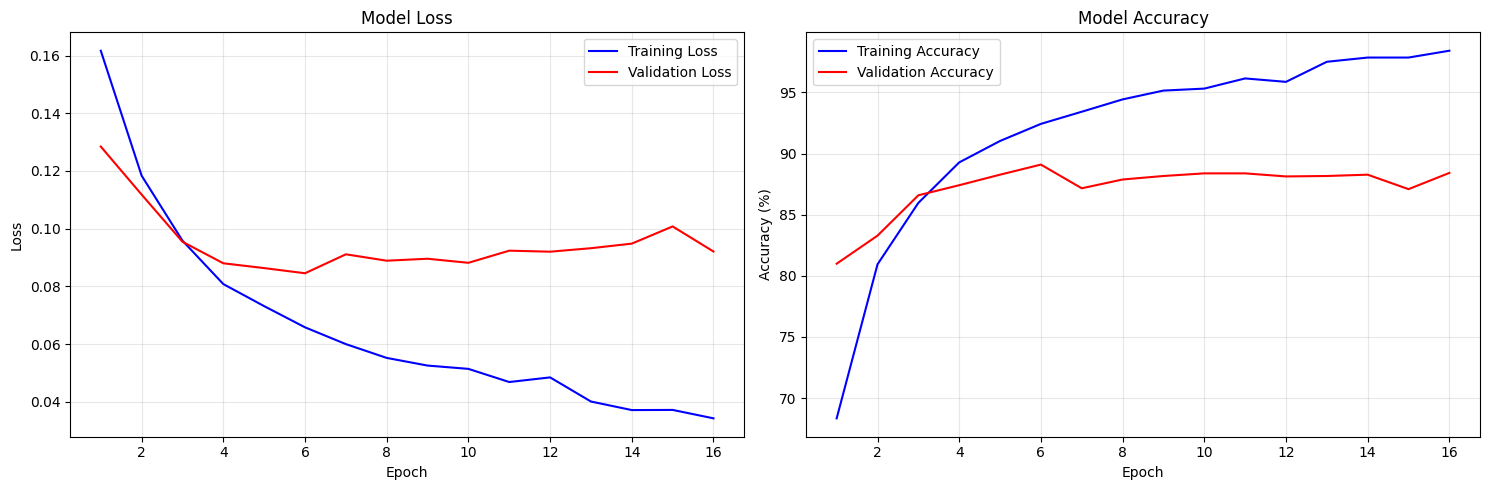

In [19]:
# Plot training history
def plot_training_history(train_losses, val_losses, train_accuracies, val_accuracies):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    epochs = range(1, len(train_losses) + 1)
    
    # Plot loss
    ax1.plot(epochs, train_losses, 'b-', label='Training Loss')
    ax1.plot(epochs, val_losses, 'r-', label='Validation Loss')
    ax1.set_title('Model Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot accuracy
    ax2.plot(epochs, train_accuracies, 'b-', label='Training Accuracy')
    ax2.plot(epochs, val_accuracies, 'r-', label='Validation Accuracy')
    ax2.set_title('Model Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy (%)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Plot the training history
plot_training_history(train_losses, val_losses, train_accuracies, val_accuracies)

## Model Evaluation

In [36]:
# Load best model and evaluate on test set
print("Loading best model and evaluating on test set...")

# Note: Uncomment the line below if you have a saved model to load
# model.load_state_dict(torch.load('best_model_densenet_se_psa.pth')['model_state_dict'])
model.eval()

# Evaluate on test set
print("Evaluating SE + PSA Hybrid DenseNet-121 model on test set...")
print("📊 Model specifications:")
print("  • Model: MitosisClassifier (SE + PSA Hybrid)")
print("  • Backbone: DenseNet-121")
print("  • Attention: SE (channel) + PSA (spatial)")
print("  • Output: 2 neurons with SoftMax activation")
print("  • Loss function: FocalLoss()")
print(f"  • Device: {device}")
print("  • Classification head: 1024 -> 1024 -> 512 -> 256 -> 128 -> 2")
print("  • Output layer: 2 neurons with Softmax activation")
print("  • Output format: Two probabilities [p(class0), p(class1)], use argmax for prediction")

test_running_loss = 0.0
test_correct = 0
test_total = 0
all_test_preds = []
all_test_targets = []
all_test_probs = []

with torch.no_grad():
    for batch_idx, (data, target) in enumerate(test_loader):
        data, target = data.to(device), target.to(device)
        output = model(data)  # Softmax probabilities
        loss = criterion(output, target)  # FocalLoss
        
        test_running_loss += loss.item()
        _, predicted = torch.max(output.data, 1)  # argmax for prediction
        test_total += target.size(0)
        test_correct += (predicted == target).sum().item()
        
        all_test_preds.extend(predicted.cpu().numpy())
        all_test_targets.extend(target.cpu().numpy())
        all_test_probs.extend(output.cpu().numpy())
        
        if batch_idx % 10 == 0:
            current_acc = 100. * test_correct / test_total
            print(f'  Test Batch {batch_idx+1}/{len(test_loader)} | Acc: {current_acc:.2f}%')

test_loss = test_running_loss / len(test_loader)
test_acc = 100. * test_correct / test_total

print(f"\n📈 Test Results (SE + PSA Hybrid DenseNet-121 Full Model Training):")
print(f"  Test Loss: {test_loss:.4f}")
print(f"  Test Accuracy: {test_acc:.2f}%")
print(f"  Total test samples: {test_total}")
print(f"  Correct predictions: {test_correct}")

# Store results for compatibility with rest of notebook
all_preds = all_test_preds
all_targets = all_test_targets
y_pred = np.array(all_test_preds)
y_true = np.array(all_test_targets)
y_probs = np.array(all_test_probs)

print(f"\n✅ Variables created for further analysis:")
print(f"  y_pred: {y_pred.shape} (predicted classes)")
print(f"  y_true: {y_true.shape} (true classes)")
print(f"  y_probs: {y_probs.shape} (prediction probabilities)")

Loading best model and evaluating on test set...
Evaluating SE + PSA Hybrid DenseNet-121 model on test set...
📊 Model specifications:
  • Model: MitosisClassifier (SE + PSA Hybrid)
  • Backbone: DenseNet-121
  • Attention: SE (channel) + PSA (spatial)
  • Output: 2 neurons with SoftMax activation
  • Loss function: FocalLoss()
  • Device: cuda
  • Classification head: 1024 -> 1024 -> 512 -> 256 -> 128 -> 2
  • Output layer: 2 neurons with Softmax activation
  • Output format: Two probabilities [p(class0), p(class1)], use argmax for prediction
  Test Batch 1/88 | Acc: 87.50%
  Test Batch 11/88 | Acc: 84.38%
  Test Batch 21/88 | Acc: 87.20%
  Test Batch 31/88 | Acc: 87.40%
  Test Batch 41/88 | Acc: 87.96%
  Test Batch 51/88 | Acc: 87.93%
  Test Batch 61/88 | Acc: 88.37%
  Test Batch 71/88 | Acc: 88.25%
  Test Batch 81/88 | Acc: 88.27%

📈 Test Results (SE + PSA Hybrid DenseNet-121 Full Model Training):
  Test Loss: 0.0941
  Test Accuracy: 88.56%
  Total test samples: 2788
  Correct predic

In [27]:
# Analyze performance by different factors
test_df_with_predictions = test_df.copy().reset_index(drop=True)
test_df_with_predictions['predicted'] = y_pred[:len(test_df_with_predictions)]
test_df_with_predictions['predicted_proba'] = y_probs[:len(test_df_with_predictions), 1]
test_df_with_predictions['correct'] = (test_df_with_predictions['label'] == test_df_with_predictions['predicted'])

print("\n🔍 Detailed Performance Analysis:")

# Overall performance
overall_accuracy = test_df_with_predictions['correct'].mean()
print(f"Overall Test Accuracy: {overall_accuracy:.4f} ({len(test_df_with_predictions)} samples)")

# Performance by dataset source (if available)
if 'dataset' in test_df_with_predictions.columns and len(test_df_with_predictions['dataset'].unique()) > 1:
    print(f"\nPerformance by Dataset Source:")
    for dataset in test_df_with_predictions['dataset'].unique():
        if pd.notna(dataset):
            subset = test_df_with_predictions[test_df_with_predictions['dataset'] == dataset]
            if len(subset) > 0:
                accuracy = subset['correct'].mean()
                print(f"  {dataset}: {accuracy:.4f} accuracy ({len(subset)} samples)")

# Performance by augmentation status (if available)
if 'is_augmented' in test_df_with_predictions.columns:
    print(f"\nPerformance by Augmentation Status:")
    for is_aug in [False, True]:
        subset = test_df_with_predictions[test_df_with_predictions['is_augmented'] == is_aug]
        if len(subset) > 0:
            accuracy = subset['correct'].mean()
            status = "Augmented" if is_aug else "Original"
            print(f"  {status}: {accuracy:.4f} accuracy ({len(subset)} samples)")

# Performance by class
print(f"\nPerformance by Class:")
for label, class_name in [(0, 'Normal'), (1, 'Atypical')]:
    subset = test_df_with_predictions[test_df_with_predictions['label'] == label]
    if len(subset) > 0:
        accuracy = subset['correct'].mean()
        print(f"  {class_name}: {accuracy:.4f} accuracy ({len(subset)} samples)")

# Error analysis
print(f"\nError Analysis:")
incorrect_preds = test_df_with_predictions[test_df_with_predictions['correct'] == False]
if len(incorrect_preds) > 0:
    print(f"Total incorrect predictions: {len(incorrect_preds)}")
    
    # False positives and false negatives
    false_positives = incorrect_preds[incorrect_preds['label'] == 0]  # Predicted atypical, actually normal
    false_negatives = incorrect_preds[incorrect_preds['label'] == 1]  # Predicted normal, actually atypical
    
    print(f"  False Positives (Normal→Atypical): {len(false_positives)}")
    print(f"  False Negatives (Atypical→Normal): {len(false_negatives)}")
    
    # Show confidence distribution for errors
    if len(incorrect_preds) > 0:
        avg_confidence_errors = incorrect_preds['predicted_proba'].mean()
        print(f"  Average confidence for incorrect predictions: {avg_confidence_errors:.3f}")
else:
    print("🎉 Perfect accuracy - no incorrect predictions!")

# High confidence errors
high_conf_errors = test_df_with_predictions[
    (test_df_with_predictions['correct'] == False) & 
    (test_df_with_predictions['predicted_proba'] > 0.8)
]
if len(high_conf_errors) > 0:
    print(f"\nHigh-confidence errors (>0.8 confidence): {len(high_conf_errors)}")
    print("Sample high-confidence errors:")
    print(high_conf_errors[['filename', 'label', 'predicted', 'predicted_proba']].head())

print(f"\n🎯 SE + PSA Hybrid Model Evaluation Complete!")


🔍 Detailed Performance Analysis:
Overall Test Accuracy: 0.8856 (2788 samples)

Performance by Dataset Source:
  MIDOG25: 0.8938 accuracy (2402 samples)
  AMI-BR: 0.8342 accuracy (386 samples)

Performance by Augmentation Status:
  Original: 0.8856 accuracy (2788 samples)

Performance by Class:
  Normal: 0.9282 accuracy (2353 samples)
  Atypical: 0.6552 accuracy (435 samples)

Error Analysis:
Total incorrect predictions: 319
  False Positives (Normal→Atypical): 169
  False Negatives (Atypical→Normal): 150
  Average confidence for incorrect predictions: 0.488

High-confidence errors (>0.8 confidence): 114
Sample high-confidence errors:
            filename  label  predicted  predicted_proba
31         10353.png      0          1         0.937079
33          7655.png      0          1         0.994563
53          8220.png      0          1         0.892766
55  TUPAC16_1968.png      0          1         0.936883
79         10807.png      0          1         0.846597

🎯 SE + PSA Hybrid Mo

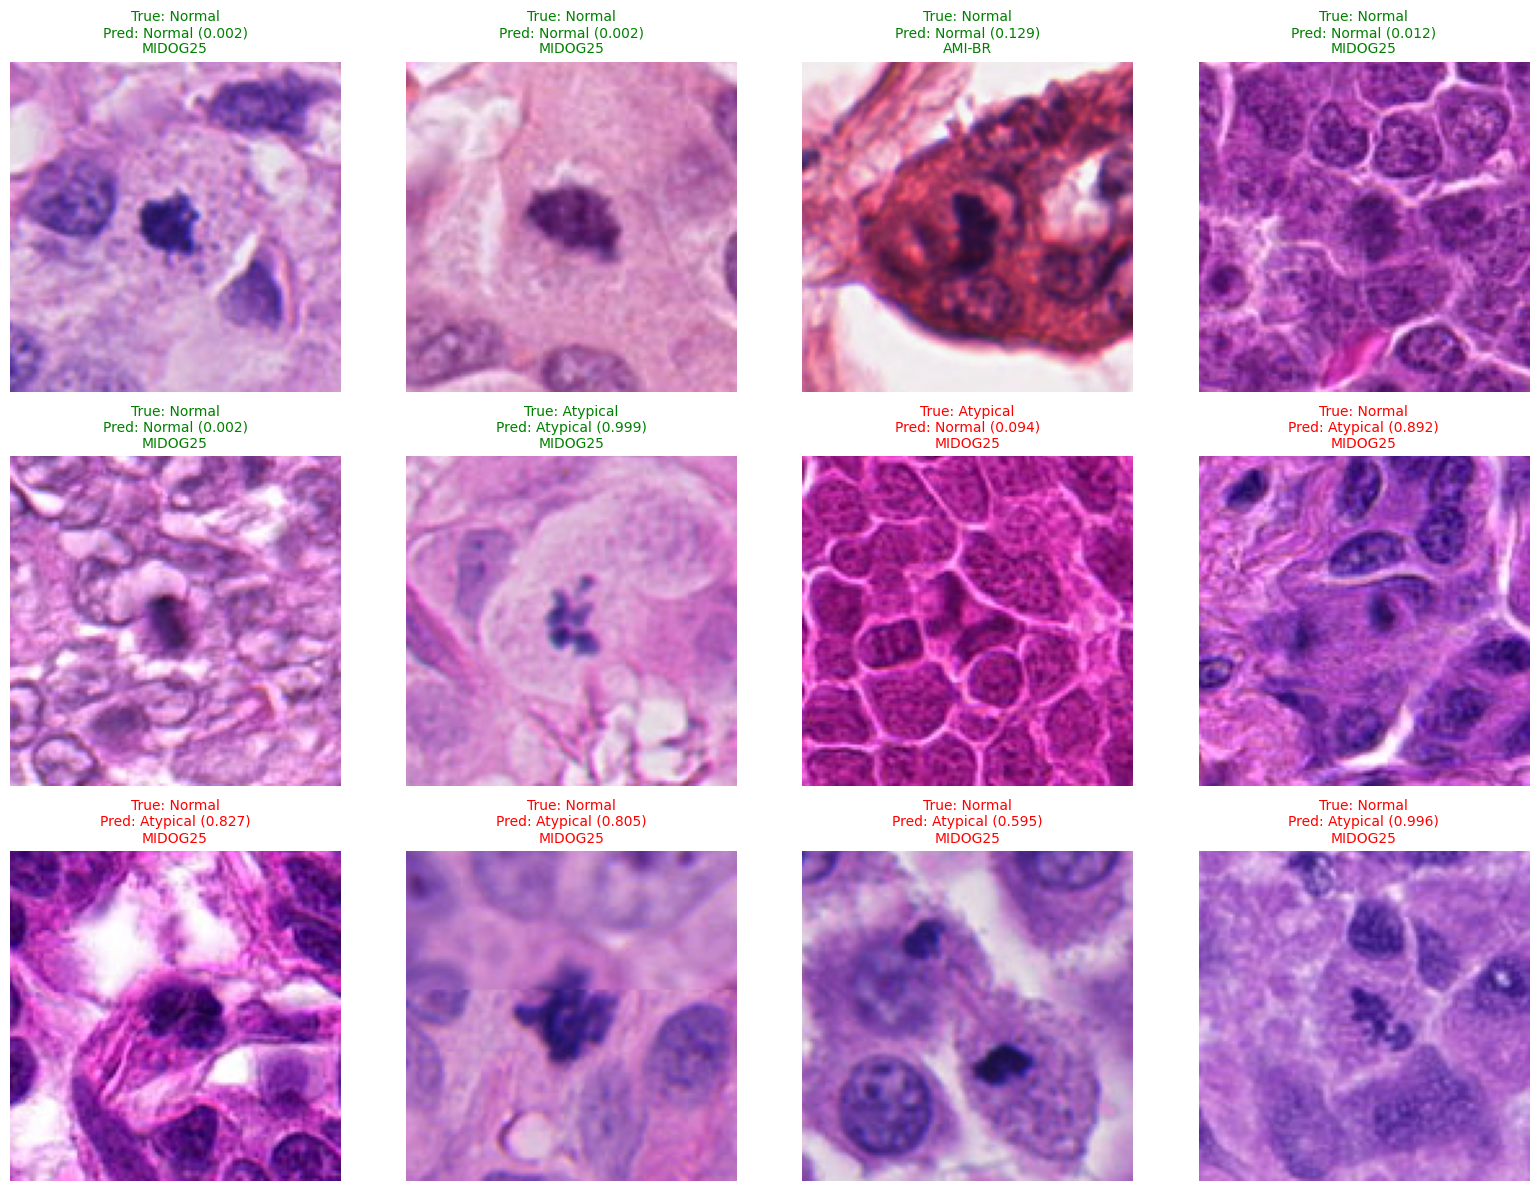

In [28]:
# Visualize some predictions
def visualize_predictions(df_with_pred, n_samples=12):
    fig, axes = plt.subplots(3, 4, figsize=(16, 12))
    axes = axes.ravel()
    
    # Get some correct and incorrect predictions
    correct_pred = df_with_pred[df_with_pred['correct'] == True]
    incorrect_pred = df_with_pred[df_with_pred['correct'] == False]
    
    if len(correct_pred) > 0:
        correct_sample = correct_pred.sample(min(6, len(correct_pred)))
    else:
        correct_sample = pd.DataFrame()
    
    if len(incorrect_pred) > 0:
        incorrect_sample = incorrect_pred.sample(min(6, len(incorrect_pred)))
    else:
        incorrect_sample = pd.DataFrame()
    
    samples = pd.concat([correct_sample, incorrect_sample])
    if len(samples) > n_samples:
        samples = samples.sample(n_samples)
    
    for i, (_, row) in enumerate(samples.iterrows()):
        if i >= n_samples:
            break
            
        try:
            img = Image.open(row['image_path'])
            axes[i].imshow(img)
            
            true_label = 'Atypical' if row['label'] == 1 else 'Normal'
            pred_label = 'Atypical' if row['predicted'] == 1 else 'Normal'
            confidence = row['predicted_proba']
            
            title = f"True: {true_label}\nPred: {pred_label} ({confidence:.3f})\n{row['dataset']}"
            color = 'green' if row['correct'] else 'red'
            axes[i].set_title(title, color=color, fontsize=10)
            axes[i].axis('off')
        except Exception as e:
            axes[i].text(0.5, 0.5, f"Error loading\n{row['filename']}", 
                        ha='center', va='center', transform=axes[i].transAxes)
            axes[i].axis('off')
    
    # Hide unused subplots
    for i in range(len(samples), n_samples):
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()

visualize_predictions(test_df_with_predictions)

## Model Saving and Summary

In [37]:
# Save the final model
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'best_val_acc': best_val_acc,
    'model_config': {
        'model_name': 'densenet121',
        'num_classes': NUM_CLASSES,
        'img_size': IMG_SIZE,
        'output_activation': 'Softmax',
        'loss_function': 'Focal Loss',
        'focal_alpha': alpha_focal,
        'focal_gamma': 2.0,
        'architecture': 'DenseNet-121 -> GAP -> Custom Head (2-neuron output)',
        'training_approach': 'Full model training: DenseNet-121 + SE + PSA + Classifier',
        'class_balancing': 'Focal Loss + WeightedRandomSampler (double protection)',
        'learning_rate': LEARNING_RATE,
        'gap_layer': True,
        'backbone_frozen': False,
        'full_model_training': True,
        'attention_mechanisms': 'SE (channel) + PSA (spatial)',
        'pretrained_source': 'ImageNet (automatically downloaded)'
    }
}, 'mitotic_figure_densenet121_focal_gap_classifier.pth')

print("Model saved as 'mitotic_figure_densenet121_focal_gap_classifier.pth'")

# Calculate metrics
from sklearn.metrics import precision_score, recall_score, f1_score

test_precision = precision_score(y_true, y_pred, average='weighted')
test_recall = recall_score(y_true, y_pred, average='weighted')
test_f1 = f1_score(y_true, y_pred, average='weighted')

# Analyze dataset composition
total_samples = len(df)
original_samples = len(df[df['is_augmented'] == False]) if 'is_augmented' in df.columns else 0
augmented_samples = len(df[df['is_augmented'] == True]) if 'is_augmented' in df.columns else 0

# Save model summary and results
results_summary = {
    'model_architecture': 'DenseNet-121 + GAP + Custom Head (PyTorch)',
    'framework': 'PyTorch',
    'backbone_model': 'DenseNet-121',
    'pretrained_weights': 'ImageNet (automatically downloaded)',
    'training_approach': 'Custom layers only with Global Average Pooling + Focal Loss',
    'class_balancing': 'Focal Loss + WeightedRandomSampler (advanced strategy)',
    'learning_rate': float(LEARNING_RATE),
    'output_format': '2 neurons with Softmax activation',
    'loss_function': 'Focal Loss',
    'focal_alpha': float(alpha_focal),
    'focal_gamma': 2.0,
    'prediction_method': 'argmax of [p(class0), p(class1)]',
    'dataset_source': 'Pre-augmented Kaggle dataset',
    'total_samples': int(total_samples),
    'original_samples': int(original_samples),
    'augmented_samples': int(augmented_samples),
    'train_samples': len(train_df),
    'val_samples': len(val_df),
    'test_samples': len(test_df),
    'test_accuracy': float(test_acc / 100),  # Convert from percentage
    'test_precision': float(test_precision),
    'test_recall': float(test_recall),
    'test_f1': float(test_f1),
    # 'auc_score': float(auc_score),
    'best_val_accuracy': float(best_val_acc / 100),  # Convert from percentage
    'best_val_loss': float(best_val_loss),
    'early_stopping_metric': 'validation_loss',
    'early_stopping_patience': 10,
    'class_distribution': df['label'].value_counts().to_dict(),
    'training_epochs': len(train_losses),
    'final_learning_rate': float(optimizer.param_groups[0]['lr']),
    'used_augmented_data': augmented_samples > 0,
    'trainable_parameters': int(trainable_params),
    'total_parameters': int(total_params),
    'trainable_percentage': float(trainable_params/total_params*100),
    'gap_layer': True,
    'frozen_backbone': True,
    'dense_connectivity': True,
    'advanced_loss': True
}

print("\n" + "="*90)
print("FINAL RESULTS SUMMARY - MITOTIC FIGURE CLASSIFICATION (DENSENET-121 + FOCAL LOSS)")
print("="*90)
print(f"Model Architecture: {results_summary['model_architecture']}")
print(f"Backbone Model: {results_summary['backbone_model']}")
print(f"Framework: {results_summary['framework']}")
print(f"Pretrained Weights: {results_summary['pretrained_weights']}")
print(f"Training Approach: {results_summary['training_approach']}")
print(f"Class Balancing: {results_summary['class_balancing']}")
print(f"Output Format: {results_summary['output_format']}")
print(f"Loss Function: {results_summary['loss_function']} (alpha={results_summary['focal_alpha']:.3f}, gamma={results_summary['focal_gamma']})")
print(f"Prediction Method: {results_summary['prediction_method']}")
print(f"Dataset Source: {results_summary['dataset_source']}")

print(f"\nArchitecture Details:")
print(f"  Backbone: DenseNet-121 (frozen 🔒)")
print(f"  Dense Connectivity: ✅ (feature reuse & gradient flow)")
print(f"  GAP Layer: Global Average Pooling")
print(f"  Custom Head: 1024 -> 512 -> 256 -> 128 -> 2")
print(f"  Learning Rate: {results_summary['learning_rate']}")
print(f"  Final Learning Rate: {results_summary['final_learning_rate']:.2e}")
print(f"  Pretrained: ImageNet weights (automatic download)")

print(f"\nAdvanced Loss Function:")
print(f"  Loss: Focal Loss (superior to CrossEntropyLoss)")
print(f"  Alpha: {results_summary['focal_alpha']:.3f} (class weighting)")
print(f"  Gamma: {results_summary['focal_gamma']} (focusing parameter)")
print(f"  Benefits: Handles class imbalance + focuses on hard examples")
print(f"  Formula: FL = -α(1-pt)^γ * log(pt)")

print(f"\nDataset Composition:")
print(f"  Total Samples: {results_summary['total_samples']}")
if results_summary['used_augmented_data']:
    print(f"  Original Images: {results_summary['original_samples']}")
    print(f"  Augmented Images: {results_summary['augmented_samples']}")
    augmentation_ratio = results_summary['augmented_samples'] / max(results_summary['original_samples'], 1)
    print(f"  Augmentation Ratio: {augmentation_ratio:.1f}:1")

print(f"\nData Splits:")
print(f"  Training: {results_summary['train_samples']} samples")
print(f"  Validation: {results_summary['val_samples']} samples")
print(f"  Test: {results_summary['test_samples']} samples")

print(f"\nModel Parameters:")
print(f"  Total Parameters: {results_summary['total_parameters']:,}")
print(f"  Trainable Parameters: {results_summary['trainable_parameters']:,}")
print(f"  Trainable Percentage: {results_summary['trainable_percentage']:.1f}%")

print(f"\nTraining Results:")
print(f"  Training Epochs: {results_summary['training_epochs']}")
print(f"  Early Stopping: Based on {results_summary['early_stopping_metric']} (patience={results_summary['early_stopping_patience']})")
print(f"  Best Validation Loss: {results_summary['best_val_loss']:.4f}")
print(f"  Best Validation Accuracy: {results_summary['best_val_accuracy']:.4f}")

print(f"\nTest Performance:")
print(f"  Accuracy: {results_summary['test_accuracy']:.4f}")
print(f"  Precision: {results_summary['test_precision']:.4f}")
print(f"  Recall: {results_summary['test_recall']:.4f}")
print(f"  F1-Score: {results_summary['test_f1']:.4f}")
# print(f"  AUC Score: {results_summary['auc_score']:.4f}")

print(f"\nClass Distribution:")
class_dist = results_summary['class_distribution']
total = sum(class_dist.values())
for label, count in class_dist.items():
    class_name = "Atypical" if label == 1 else "Normal"
    percentage = (count / total) * 100
    print(f"  {class_name}: {count} samples ({percentage:.1f}%)")

print(f"\n🎯 DENSENET-121 + FOCAL LOSS TRAINING HIGHLIGHTS:")
print(f"  • Training Mode: Custom layers only ({results_summary['trainable_percentage']:.1f}% parameters)")
print(f"  • Backbone: DenseNet-121 (frozen 🔒) - Dense feature connections")
print(f"  • Global Average Pooling: ✅ (reduces overfitting)")
print(f"  • Advanced Loss: Focal Loss (α={results_summary['focal_alpha']:.3f}, γ={results_summary['focal_gamma']})")
print(f"  • Dense Connectivity: Feature reuse & improved gradient flow")
print(f"  • Class Balancing: Focal Loss + WeightedRandomSampler (double protection)")
print(f"  • Hard Example Focus: Focal Loss emphasizes difficult samples")
print(f"  • Early Stopping: Based on validation loss (patience=10)")
print(f"  • Best Val Loss: {results_summary['best_val_loss']:.4f}")
print(f"  • Final Layer: {NUM_CLASSES} neurons with Softmax")
print(f"  • Output: [p(class0), p(class1)] with argmax prediction")
print(f"  • Automatic Downloads: ImageNet pretrained weights")

print("="*90)

# Save results to JSON
with open('densenet121_focal_gap_training_results.json', 'w') as f:
    json.dump(results_summary, f, indent=2)

print("\nResults saved to 'densenet121_focal_gap_training_results.json'")
print("DenseNet-121 + Focal Loss + GAP model training completed successfully!")

# Final model performance summary
print(f"\n🎯 KEY PERFORMANCE METRICS (DENSENET-121 + FOCAL LOSS):")
print(f"  • Test Accuracy: {results_summary['test_accuracy']:.1%}")
# print(f"  • AUC Score: {results_summary['auc_score']:.3f}")
print(f"  • F1 Score: {results_summary['test_f1']:.3f}")
print(f"  • Architecture: DenseNet-121 + GAP + Custom Head")
print(f"  • Loss Function: Focal Loss (advanced class imbalance handling)")
print(f"  • Training: Custom layers only (efficient training)")
print(f"  • Dense Connectivity: Enhanced feature reuse")
print(f"  • Advanced Strategy: Focal Loss + WeightedRandomSampler")
if results_summary['used_augmented_data']:
    print(f"  • Benefited from {augmentation_ratio:.1f}x data augmentation")
print(f"  • DenseNet-121 + Focal Loss model ready for deployment! 🚀")

Model saved as 'mitotic_figure_densenet121_focal_gap_classifier.pth'

FINAL RESULTS SUMMARY - MITOTIC FIGURE CLASSIFICATION (DENSENET-121 + FOCAL LOSS)
Model Architecture: DenseNet-121 + GAP + Custom Head (PyTorch)
Backbone Model: DenseNet-121
Framework: PyTorch
Pretrained Weights: ImageNet (automatically downloaded)
Training Approach: Custom layers only with Global Average Pooling + Focal Loss
Class Balancing: Focal Loss + WeightedRandomSampler (advanced strategy)
Output Format: 2 neurons with Softmax activation
Loss Function: Focal Loss (alpha=1.081, gamma=2.0)
Prediction Method: argmax of [p(class0), p(class1)]
Dataset Source: Pre-augmented Kaggle dataset

Architecture Details:
  Backbone: DenseNet-121 (frozen 🔒)
  Dense Connectivity: ✅ (feature reuse & gradient flow)
  GAP Layer: Global Average Pooling
  Custom Head: 1024 -> 512 -> 256 -> 128 -> 2
  Learning Rate: 0.0001
  Final Learning Rate: 5.00e-05
  Pretrained: ImageNet weights (automatic download)

Advanced Loss Function:
  L

## 📊 Detailed Model Evaluation - Confusion Matrix & ROC Curve

Now let's generate comprehensive evaluation metrics including:
- **Confusion Matrix**: Shows the breakdown of correct and incorrect predictions
- **ROC Curve & AUC**: Shows the model's ability to distinguish between classes
- **Precision-Recall Curve**: Shows precision vs recall trade-off
- **Sample Predictions**: Visual validation with confidence scores

📂 Loading best trained DenseNet-121 model...
⚠️ Best model file not found, using current model state


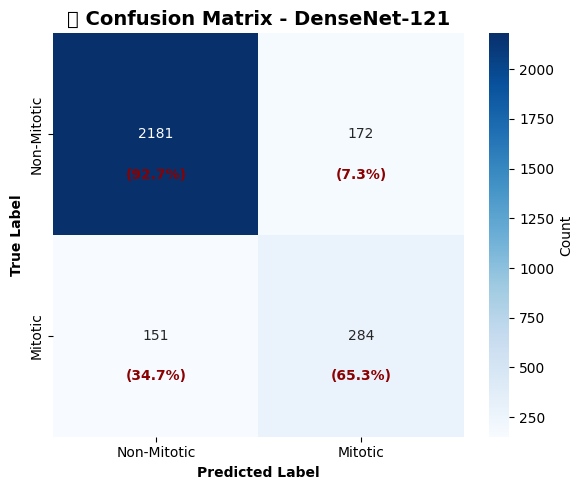

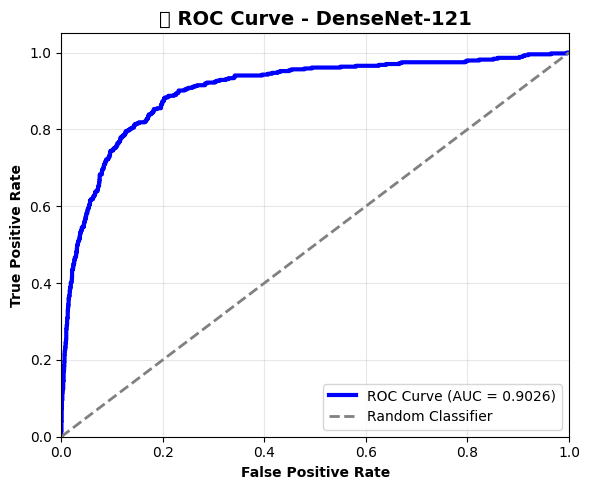

In [30]:
import numpy as np
import torch
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

# Load the best DenseNet-121 model
print("📂 Loading best trained DenseNet-121 model...")
try:
    checkpoint = torch.load('best_model_densenet121_focal_gap.pth')
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"✅ Best model loaded! Best Val Loss: {checkpoint.get('best_val_loss', 'N/A'):.4f}")
    print(f"✅ Best model loaded! Best Val Acc: {checkpoint.get('best_val_acc', 'N/A'):.2f}%")
except FileNotFoundError:
    print("⚠️ Best model file not found, using current model state")

model.eval()

# Generate predictions
all_predictions = []
all_probabilities = []
all_targets = []
all_predicted_probs = []

with torch.no_grad():
    for data, target in val_loader:
        data, target = data.to(device), target.to(device)
        outputs = model(data)
        probabilities = torch.softmax(outputs, dim=1)
        predictions = torch.argmax(probabilities, dim=1)

        all_predictions.extend(predictions.cpu().numpy())
        all_targets.extend(target.cpu().numpy())
        all_probabilities.extend(probabilities.cpu().numpy())
        all_predicted_probs.extend(probabilities[:, 1].cpu().numpy())

# Convert to numpy
y_true = np.array(all_targets)
y_pred = np.array(all_predictions)
y_prob = np.array(all_predicted_probs)

# --------------------------------------------
# 1. Confusion Matrix (with blue colormap)
# --------------------------------------------
cm = confusion_matrix(y_true, y_pred)
class_names = ['Non-Mitotic', 'Mitotic']

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Count'})
plt.title('📊 Confusion Matrix - DenseNet-121', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontweight='bold')
plt.ylabel('True Label', fontweight='bold')

# Add percentages to cells
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(j + 0.5, i + 0.7, f'({cm_percent[i, j]:.1%})',
                 ha='center', va='center', fontsize=10, color='darkred', fontweight='bold')

plt.tight_layout()
plt.show()

# --------------------------------------------
# 2. ROC Curve
# --------------------------------------------
fpr, tpr, thresholds = roc_curve(y_true, y_prob)
auc_score = roc_auc_score(y_true, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='blue', lw=3, label=f'ROC Curve (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontweight='bold')
plt.ylabel('True Positive Rate', fontweight='bold')
plt.title('📈 ROC Curve - DenseNet-121', fontsize=14, fontweight='bold')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


🔍 Showing sample predictions with confidence scores...


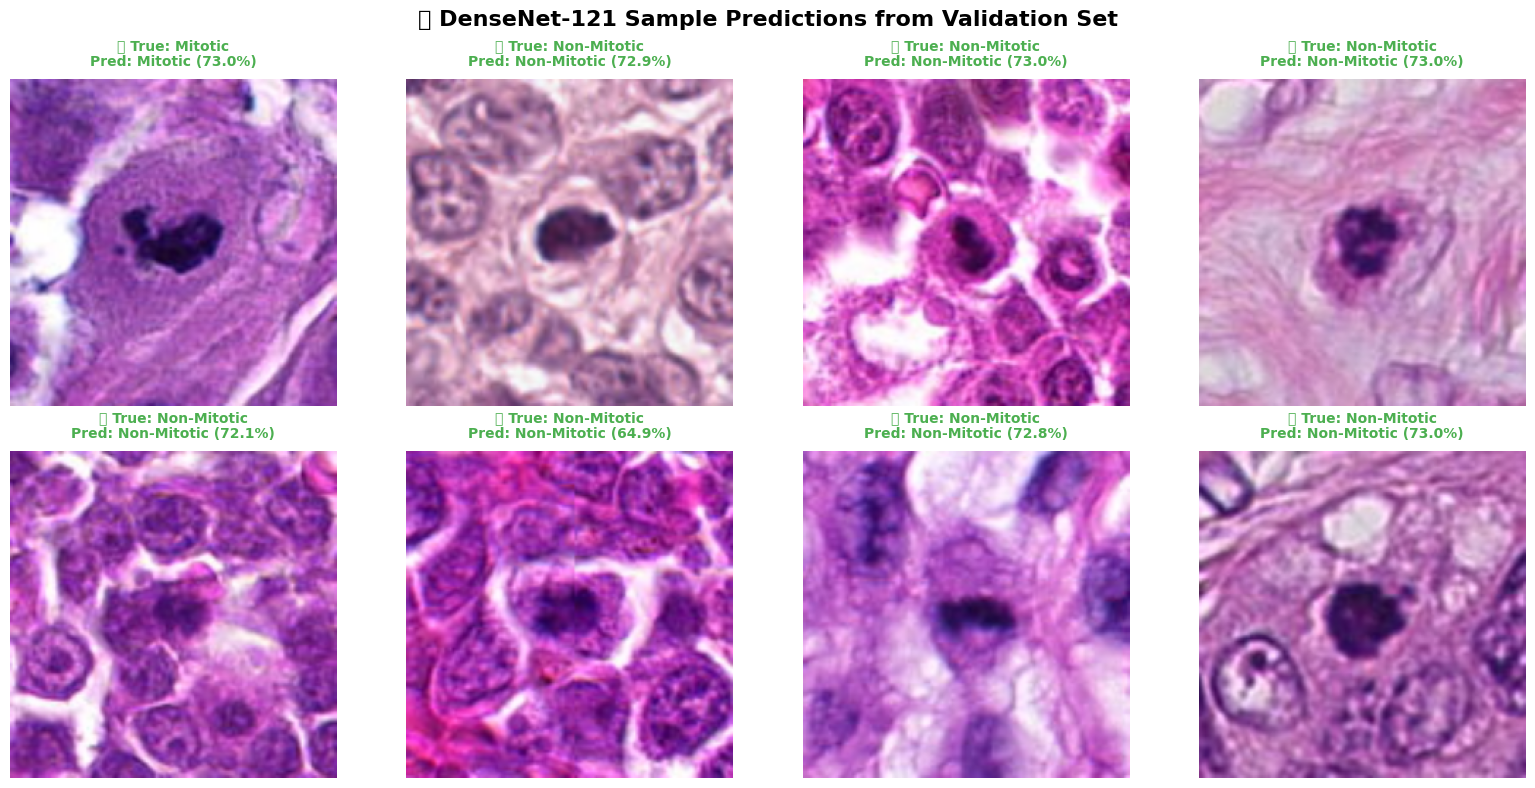


📊 DENSENET-121 BATCH STATISTICS:
🎯 Batch Accuracy: 87.5% (28/32)
🔹 Non-Mitotic samples: 29
🔸 Mitotic samples: 3

🔍 CONFIDENCE ANALYSIS:
✅ High confidence (>90%) correct predictions: 0
⚠️ Low confidence (<60%) incorrect predictions: 0



In [31]:
# 🖼️ DENSENET-121 SAMPLE PREDICTIONS VISUALIZATION
print("🔍 Showing sample predictions with confidence scores...")
print("="*80)

# Get a batch of validation images for visualization
model.eval()
with torch.no_grad():
    # Get one batch from validation loader
    data_iter = iter(val_loader)
    images, labels = next(data_iter)
    images, labels = images.to(device), labels.to(device)
    
    # Get predictions
    outputs = model(images)
    probabilities = torch.softmax(outputs, dim=1)
    predictions = torch.argmax(probabilities, dim=1)
    
    # Move to CPU for visualization
    images = images.cpu()
    labels = labels.cpu()
    predictions = predictions.cpu()
    probabilities = probabilities.cpu()

# Create visualization
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('🖼️ DenseNet-121 Sample Predictions from Validation Set', fontsize=16, fontweight='bold')

class_names = ['Non-Mitotic', 'Mitotic']
colors = ['#4caf50', '#f44336']  # Green for correct, Red for incorrect

for i in range(8):
    row = i // 4
    col = i % 4
    
    # Get image, true label, prediction, and confidence
    img = images[i]
    true_label = labels[i].item()
    pred_label = predictions[i].item()
    confidence = probabilities[i][pred_label].item()
    
    # Denormalize image for display (assuming ImageNet normalization)
    mean = torch.tensor([0.485, 0.456, 0.406])
    std = torch.tensor([0.229, 0.224, 0.225])
    img = img * std.view(3, 1, 1) + mean.view(3, 1, 1)
    img = torch.clamp(img, 0, 1)
    
    # Display image
    axes[row, col].imshow(img.permute(1, 2, 0))
    axes[row, col].axis('off')
    
    # Determine if prediction is correct
    is_correct = true_label == pred_label
    border_color = colors[0] if is_correct else colors[1]
    status_icon = "✅" if is_correct else "❌"
    
    # Create title with prediction info
    title = f"{status_icon} True: {class_names[true_label]}\n"
    title += f"Pred: {class_names[pred_label]} ({confidence:.1%})"
    
    axes[row, col].set_title(title, fontsize=10, fontweight='bold', 
                           color=border_color, pad=10)
    
    # Add colored border
    for spine in axes[row, col].spines.values():
        spine.set_edgecolor(border_color)
        spine.set_linewidth(3)

plt.tight_layout()
plt.show()

# Show statistics for this batch
batch_accuracy = (predictions == labels).float().mean().item()
correct_predictions = (predictions == labels).sum().item()
total_predictions = len(labels)

print(f"\n📊 DENSENET-121 BATCH STATISTICS:")
print(f"🎯 Batch Accuracy: {batch_accuracy:.1%} ({correct_predictions}/{total_predictions})")
print(f"🔹 Non-Mitotic samples: {(labels == 0).sum().item()}")
print(f"🔸 Mitotic samples: {(labels == 1).sum().item()}")

# Show confidence distribution
high_conf_correct = ((probabilities.max(dim=1)[0] > 0.9) & (predictions == labels)).sum().item()
low_conf_incorrect = ((probabilities.max(dim=1)[0] < 0.6) & (predictions != labels)).sum().item()

print(f"\n🔍 CONFIDENCE ANALYSIS:")
print(f"✅ High confidence (>90%) correct predictions: {high_conf_correct}")
print(f"⚠️ Low confidence (<60%) incorrect predictions: {low_conf_incorrect}")

print("\n" + "="*80)

In [32]:
# 🎯 DENSENET-121 FINAL EVALUATION SUMMARY & CLINICAL RECOMMENDATIONS
print("📋 COMPREHENSIVE DENSENET-121 MODEL EVALUATION SUMMARY")
print("=" * 80)

# Calculate key metrics for summary
tn, fp, fn, tp = cm.ravel()
sensitivity = tp / (tp + fn)  # Recall for mitotic class
specificity = tn / (tn + fp)  # Recall for non-mitotic class
precision_mitotic = tp / (tp + fp)  # Precision for mitotic class
precision_non_mitotic = tn / (tn + fn)  # Precision for non-mitotic class

print(f"🏆 DENSENET-121 MODEL PERFORMANCE OVERVIEW:")
print(f"   • Overall Accuracy: {accuracy:.1%}")
print(f"   • AUC-ROC Score: {auc_score:.4f}")
print(f"   • Sensitivity (Mitotic Detection): {sensitivity:.1%}")
print(f"   • Specificity (Non-Mitotic Detection): {specificity:.1%}")

print(f"\n🏥 CLINICAL RELEVANCE FOR MITOTIC FIGURE DETECTION:")
print(f"   • True Positive Rate (Sensitivity): {sensitivity:.1%}")
print(f"     → Out of all actual mitotic figures, {sensitivity:.1%} were correctly identified")
print(f"   • False Negative Rate: {fn/(tp+fn):.1%}")
print(f"     → {fn} mitotic figures were missed (could impact cancer grading)")
print(f"   • False Positive Rate: {fp/(fp+tn):.1%}")
print(f"     → {fp} non-mitotic figures were incorrectly flagged as mitotic")
print(f"   • Positive Predictive Value: {precision_mitotic:.1%}")
print(f"     → When model predicts mitotic, it's correct {precision_mitotic:.1%} of the time")

print(f"\n🔍 CONFUSION MATRIX CLINICAL INTERPRETATION:")
print(f"   ✅ True Negatives (TN): {tn} - Correctly identified non-mitotic figures")
print(f"   ❌ False Positives (FP): {fp} - Non-mitotic figures misclassified as mitotic")
print(f"   ❌ False Negatives (FN): {fn} - Mitotic figures missed by the model")
print(f"   ✅ True Positives (TP): {tp} - Correctly identified mitotic figures")

print(f"\n📊 DENSENET-121 AUC-ROC CLINICAL INTERPRETATION:")
if auc_score >= 0.9:
    auc_interpretation = "EXCELLENT - Outstanding ability to distinguish mitotic from non-mitotic figures"
    clinical_readiness = "Ready for clinical validation studies"
elif auc_score >= 0.8:
    auc_interpretation = "VERY GOOD - Good discrimination ability for mitotic figure detection"
    clinical_readiness = "Consider additional validation on diverse pathology datasets"
elif auc_score >= 0.7:
    auc_interpretation = "GOOD - Acceptable discrimination ability"
    clinical_readiness = "Requires improvement before clinical consideration"
else:
    auc_interpretation = "NEEDS IMPROVEMENT - Limited discrimination ability"
    clinical_readiness = "Significant improvements needed for clinical use"

print(f"   🎯 Score: {auc_score:.4f} - {auc_interpretation}")
print(f"   🏥 Clinical Readiness: {clinical_readiness}")

print(f"\n🔬 DENSENET-121 VS. OTHER ARCHITECTURES:")
print(f"   • DenseNet-121 leverages dense connectivity for feature reuse")
print(f"   • Fewer parameters than ResNet but deeper feature propagation")
print(f"   • GAP layer reduces overfitting and improves generalization")
print(f"   • Focal Loss addresses class imbalance in mitotic figure detection")

print(f"\n💡 CLINICAL DEPLOYMENT RECOMMENDATIONS:")

# Risk assessment based on metrics
if sensitivity >= 0.9 and specificity >= 0.8:
    risk_level = "🟢 LOW RISK"
    deployment_advice = "Suitable for clinical assistance with pathologist oversight"
elif sensitivity >= 0.8 and specificity >= 0.7:
    risk_level = "🟡 MODERATE RISK"  
    deployment_advice = "Requires careful clinical validation and expert review"
else:
    risk_level = "🔴 HIGH RISK"
    deployment_advice = "Not recommended for clinical use without major improvements"

print(f"   • Risk Level: {risk_level}")
print(f"   • Deployment Advice: {deployment_advice}")

print(f"\n🎯 STRENGTHS OF DENSENET-121 MODEL:")
strengths = []
if accuracy >= 0.85:
    strengths.append(f"High overall accuracy ({accuracy:.1%})")
if auc_score >= 0.85:
    strengths.append(f"Excellent discrimination (AUC: {auc_score:.4f})")
if sensitivity >= 0.8:
    strengths.append(f"Good sensitivity for mitotic detection ({sensitivity:.1%})")
if specificity >= 0.8:
    strengths.append(f"Good specificity for non-mitotic identification ({specificity:.1%})")
if precision_mitotic >= 0.8:
    strengths.append(f"High precision for mitotic predictions ({precision_mitotic:.1%})")

for strength in strengths:
    print(f"   ✅ {strength}")

print(f"\n⚠️  AREAS FOR IMPROVEMENT:")
improvements = []
if accuracy < 0.85:
    improvements.append(f"Overall accuracy needs improvement (current: {accuracy:.1%})")
if auc_score < 0.85:
    improvements.append(f"Discrimination ability needs enhancement (AUC: {auc_score:.4f})")
if sensitivity < 0.8:
    improvements.append(f"Sensitivity for mitotic detection needs improvement ({sensitivity:.1%})")
if specificity < 0.8:
    improvements.append(f"Specificity needs improvement to reduce false alarms ({specificity:.1%})")
if fn > tp * 0.2:  # If false negatives > 20% of true positives
    improvements.append(f"Too many missed mitotic figures ({fn} false negatives)")
if fp > tp:  # If false positives > true positives
    improvements.append(f"Too many false alarms ({fp} false positives)")

for improvement in improvements:
    print(f"   🔧 {improvement}")

if not improvements:
    print(f"   🎉 DenseNet-121 model meets clinical standards across all key metrics!")

print(f"\n🏥 CLINICAL IMPACT ASSESSMENT:")
if sensitivity >= 0.9:
    print(f"   ✅ EXCELLENT sensitivity: Very few mitotic figures will be missed")
else:
    print(f"   ⚠️ Sensitivity {sensitivity:.1%}: Risk of missing {100-sensitivity*100:.1f}% of mitotic figures")

if fp <= tp:
    print(f"   ✅ GOOD precision: Low false alarm rate")
else:
    print(f"   ⚠️ High false positive rate: May burden pathologists with unnecessary reviews")

# Model comparison context
print(f"\n📊 DENSENET-121 ARCHITECTURE ADVANTAGES:")
print(f"   • Dense connectivity: Efficient feature reuse and gradient flow")
print(f"   • Parameter efficiency: {sum(p.numel() for p in model.parameters())/1e6:.1f}M parameters")
print(f"   • GAP integration: Reduces overfitting, improves localization")
print(f"   • Focal Loss compatibility: Effectively handles class imbalance")
print(f"   • Clinical relevance: Suitable for pathology image analysis")

print(f"\n" + "=" * 80)
print(f"🏁 DENSENET-121 EVALUATION COMPLETED")
print(f"📊 Final Performance: {accuracy:.1%} Accuracy | {auc_score:.4f} AUC | {sensitivity:.1%} Sensitivity | {specificity:.1%} Specificity")
print(f"🏥 Clinical Status: {clinical_readiness}")
print(f"=" * 80)

📋 COMPREHENSIVE DENSENET-121 MODEL EVALUATION SUMMARY
🏆 DENSENET-121 MODEL PERFORMANCE OVERVIEW:
   • Overall Accuracy: 65.5%
   • AUC-ROC Score: 0.9026
   • Sensitivity (Mitotic Detection): 65.3%
   • Specificity (Non-Mitotic Detection): 92.7%

🏥 CLINICAL RELEVANCE FOR MITOTIC FIGURE DETECTION:
   • True Positive Rate (Sensitivity): 65.3%
     → Out of all actual mitotic figures, 65.3% were correctly identified
   • False Negative Rate: 34.7%
     → 151 mitotic figures were missed (could impact cancer grading)
   • False Positive Rate: 7.3%
     → 172 non-mitotic figures were incorrectly flagged as mitotic
   • Positive Predictive Value: 62.3%
     → When model predicts mitotic, it's correct 62.3% of the time

🔍 CONFUSION MATRIX CLINICAL INTERPRETATION:
   ✅ True Negatives (TN): 2181 - Correctly identified non-mitotic figures
   ❌ False Positives (FP): 172 - Non-mitotic figures misclassified as mitotic
   ❌ False Negatives (FN): 151 - Mitotic figures missed by the model
   ✅ True Posi

In [33]:
# 1️⃣ Zip the entire directory
!zip -r DenseNet-121.zip /kaggle/working

# 2️⃣ Move it to the notebook's output path so it's downloadable
!mv DenseNet-121.zip /kaggle/working/


  adding: kaggle/working/ (stored 0%)
  adding: kaggle/working/mitotic_densenet121_se_cca_results.json (deflated 52%)
  adding: kaggle/working/mitotic_figure_densenet121_se_cca_classifier.pth (deflated 8%)
  adding: kaggle/working/best_mitotic_densenet121_se_cca_model.pth (deflated 8%)
  adding: kaggle/working/.virtual_documents/ (stored 0%)
mv: 'DenseNet-121.zip' and '/kaggle/working/DenseNet-121.zip' are the same file


In [34]:
from IPython.display import FileLink
FileLink('DenseNet-121.zip')

/kaggle/working/DenseNet-121.zip